# SREDJIVANJE DATASETA

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
from sklearn.cluster import KMeans
from scipy import stats
from sklearn.preprocessing import RobustScaler
import warnings
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage



warnings.simplefilter(action='ignore', category=FutureWarning)




In [2]:
data = pd.read_csv('sampleSuperstore.csv', encoding='cp1252')

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Nema ni jedne Null-vrednosti

In [5]:
data.select_dtypes(include = ['object']).nunique()

Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
dtype: int64

In [6]:
data.drop_duplicates().head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Nema ni jednog duplikata. Country je jedinstvena vrednost za sve, a Customer Name je isto sta i Customer ID. Postal Code referencira direktno na City, a pri tom nema nikakvu analiticku korisnost.

In [7]:
data = data.drop(['Country','Customer Name','Row ID','Postal Code'], axis = 1)

In [8]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

data['Month'] = data['Order Date'].dt.month
data['Year'] = data['Order Date'].dt.year
data['Days_to_Ship'] = (data['Ship Date'] - data['Order Date']).dt.days
data = data.drop(['Order Date','Ship Date'], axis=1)

In [9]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

data['Order_Season'] = data['Month'].apply(get_season)



In [10]:
object_columns = data.select_dtypes(include = ['object']).columns
for i in object_columns:
    if data[i].nunique() < 5:
        print(f'Kolona {i}:{data[i].unique()}')

Kolona Ship Mode:['Second Class' 'Standard Class' 'First Class' 'Same Day']
Kolona Segment:['Consumer' 'Corporate' 'Home Office']
Kolona Region:['South' 'West' 'Central' 'East']
Kolona Category:['Furniture' 'Office Supplies' 'Technology']
Kolona Order_Season:['Fall' 'Summer' 'Spring' 'Winter']


In [11]:
data.describe()

,Sales,Quantity,Discount,Profit,Month,Year,Days_to_Ship
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,7.809686,2015.722233,3.958175
std,623.245101,2.225110,0.206452,234.260108,3.284654,1.123555,1.747567
min,0.444000,1.000000,0.000000,-6599.978000,1.000000,2014.000000,0.000000
25%,17.280000,2.000000,0.000000,1.728750,5.000000,2015.000000,3.000000
50%,54.490000,3.000000,0.200000,8.666500,9.000000,2016.000000,4.000000
75%,209.940000,5.000000,0.200000,29.364000,11.000000,2017.000000,5.000000
max,22638.480000,14.000000,0.800000,8399.976000,12.000000,2017.000000,7.000000


Vidimo da je opseg godina 2014-2017, broj dana potrebnih za dostavu 0-7 (u proseku je potrebno 3.95 dana da stigne roba), popust ide od 0-80% popusta (u proseku je popust 15%), prodaja i profit imaju veliki opseg vrednosti.

In [12]:
data.describe(include = 'object')

,Order ID,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Order_Season
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,3,531,49,4,1862,3,17,1850,4
top,CA-2017-100111,Standard Class,WB-21850,Consumer,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,Fall
freq,14,5968,37,5191,915,2001,3203,19,6026,1523,48,3673


Broj (unique) Customer ID-ja je manji od broja porudzbina, sto znaci da su customeri imali vise porudzbina u datasetu. Broj Order ID je manji od counta, sto znaci da je jednu narudzbinu mogu ciniti vise proizvoda.

Rad cu da podelim na dva dela:
 1. Segmentacija transakcija
 2. Segmentacija korisnika

# SEGMENTACIJA TRANSAKCIJA


## Deskriptivna analiza

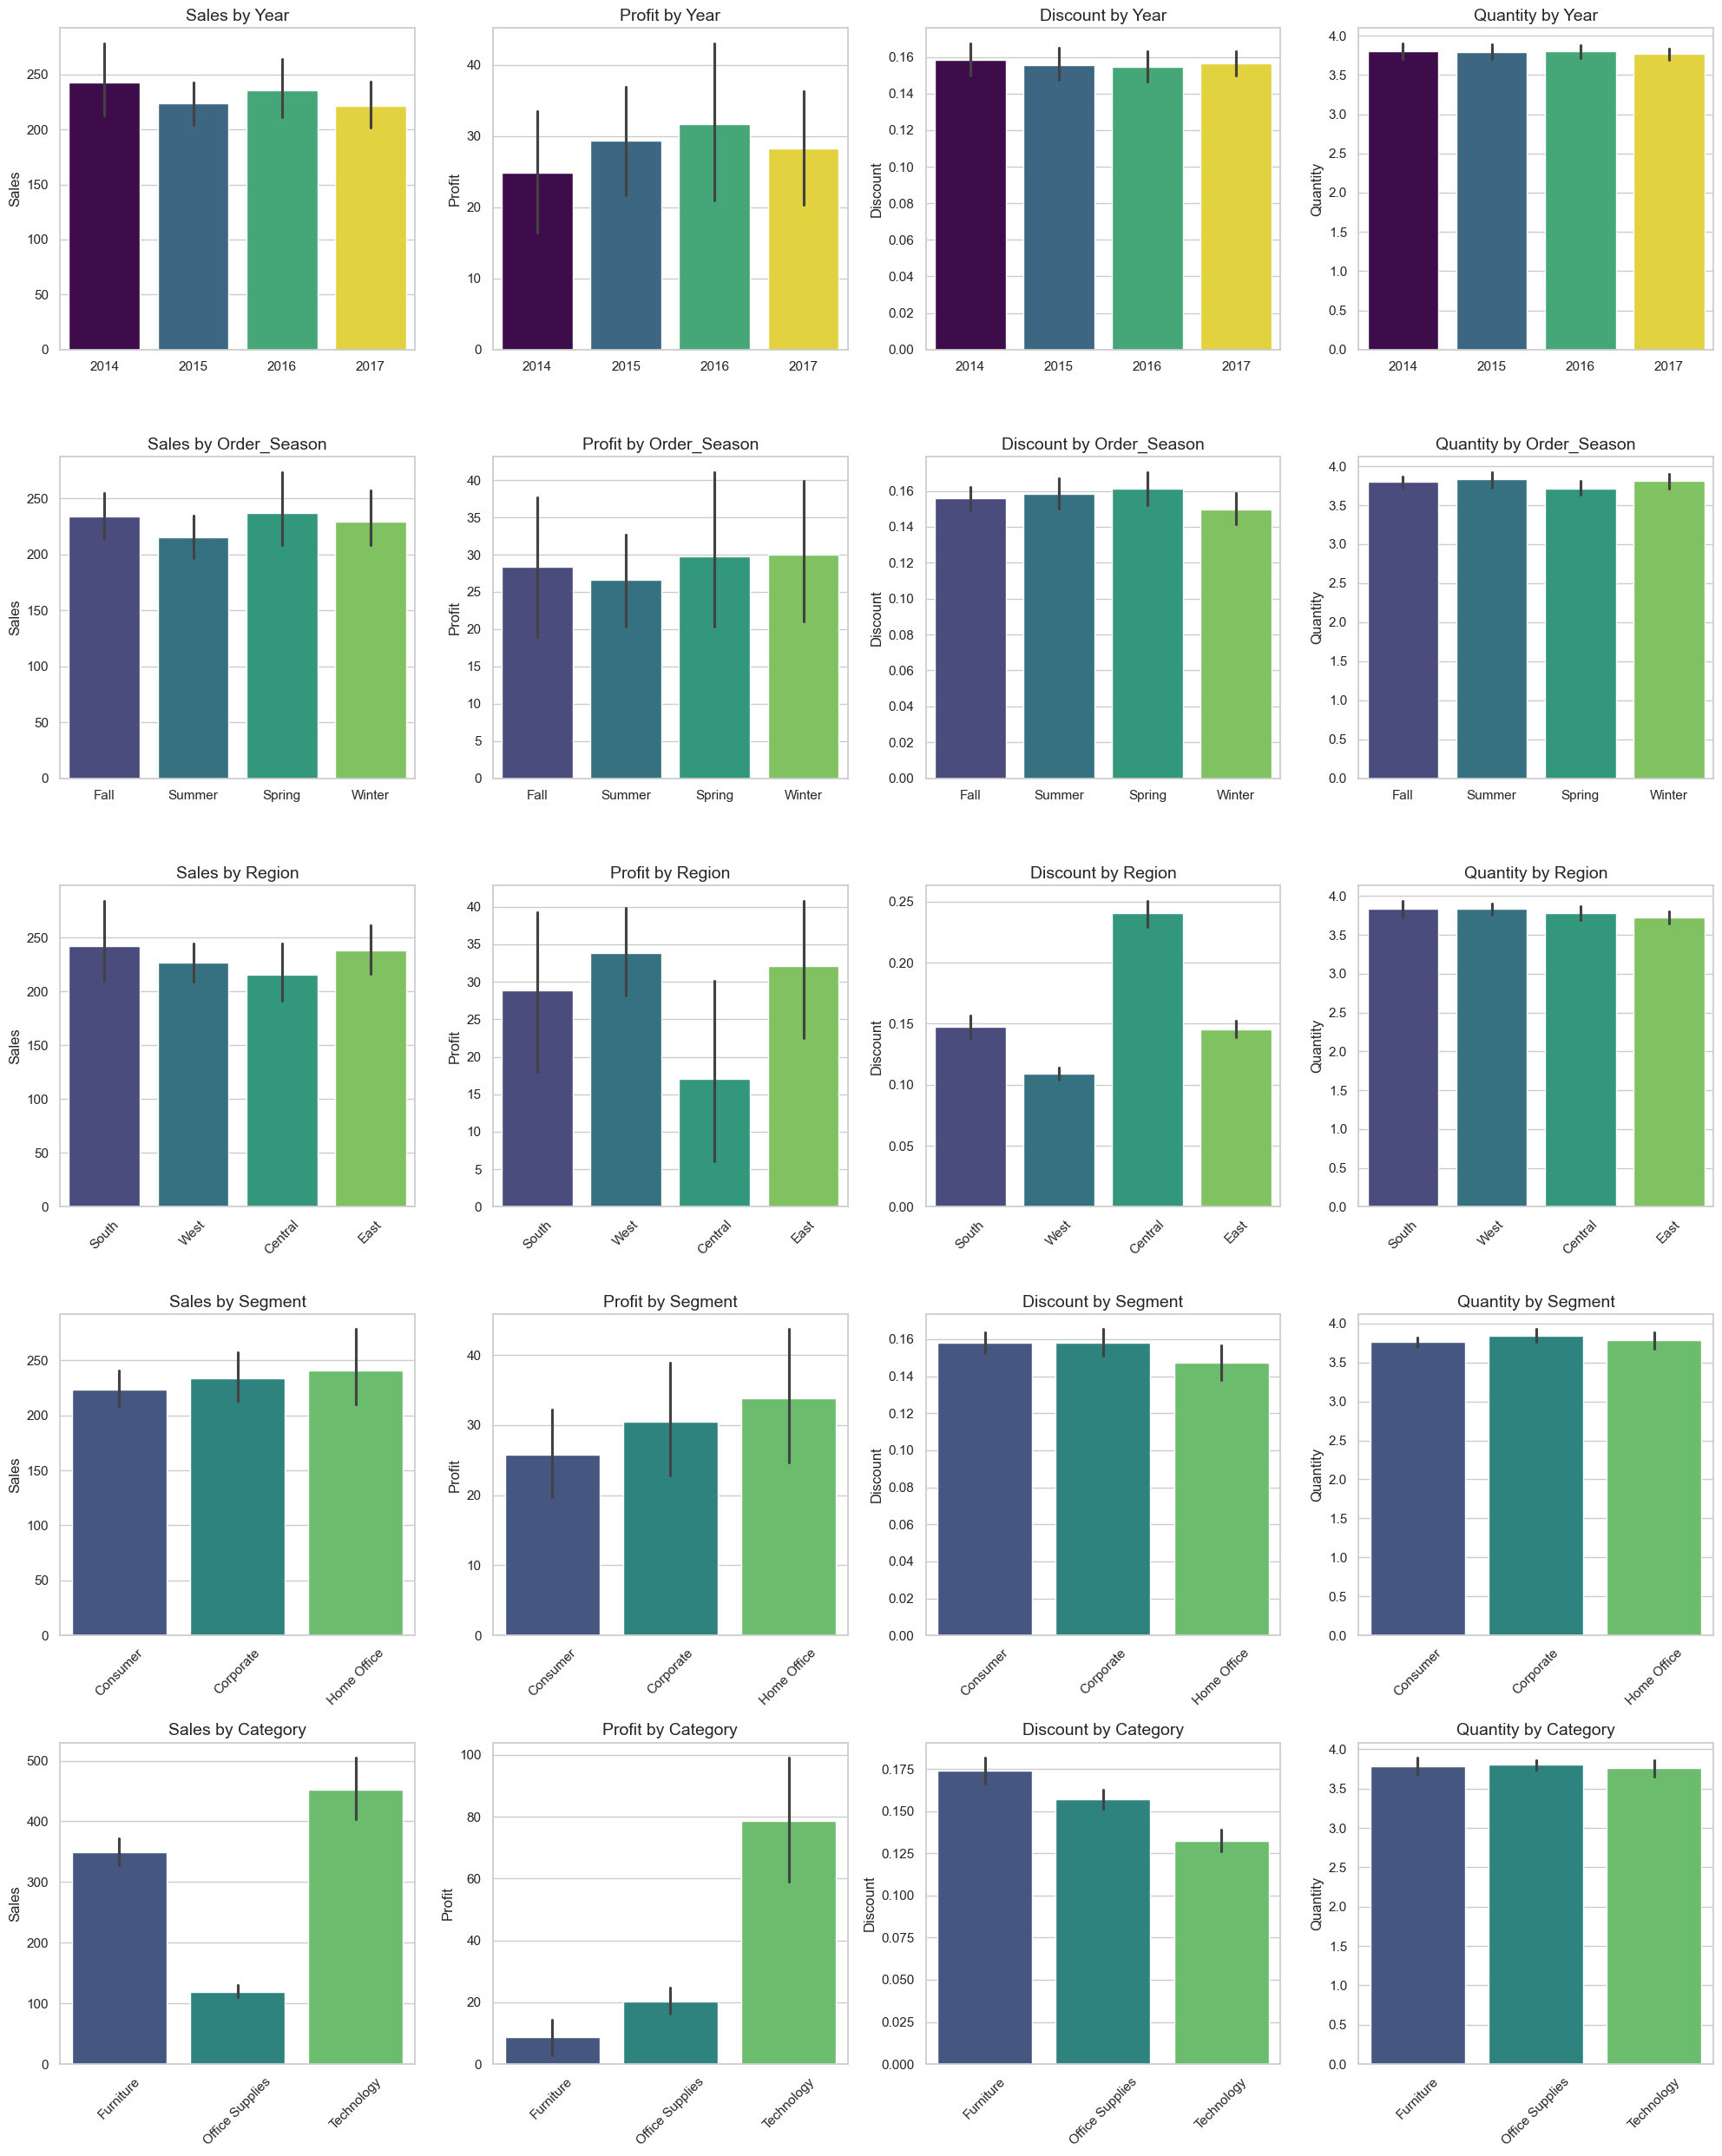

In [13]:
sns.set_theme(style="whitegrid")
metrics = ['Sales', 'Profit', 'Discount', 'Quantity']
dimensions = ['Year', 'Order_Season', 'Region', 'Segment', 'Category']

fig, axes = plt.subplots(nrows=len(dimensions), ncols=len(metrics), figsize=(20, 25))

for i, dim in enumerate(dimensions):
    for j, metric in enumerate(metrics):
        sns.barplot(ax=axes[i, j], x=dim, y=metric, data=data, palette='viridis', hue=dim, legend=False)
        
        axes[i, j].set_title(f'{metric} by {dim}', fontsize=14)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel(metric)
        
        if i >= 2: 
            axes[i, j].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Moze se primetiti da Region Central ima prosecno najvece popuste, a najmanji profit za istu kolicinu prodaje. Isto to se moze primetiti i za Category, gde veci popsusti za Furniture i Office Supplies uslovljavaju nize profite.

Hajde da posmatramo Profits.

In [14]:
region_grouped = data.groupby('Region')[['Sales','Profit','Discount','Quantity']].mean()
region_grouped

,Sales,Profit,Discount,Quantity
Region,,,,
Central,215.772661,17.092709,0.240353,3.779595
East,238.336110,32.135808,0.145365,3.728230
South,241.803645,28.857673,0.147253,3.832716
West,226.493233,33.849032,0.109335,3.829535


Lable Encoding:

Central - 0 - veliki popust/najmanji profit

South - 1 - srednjipopusti/srednji profit,

East -2 - srednji popust/veliki profit

West - 3 - mali popust/veliki profit

In [15]:
category_grouped = data.groupby('Category')[['Sales','Profit','Discount','Quantity']].mean()
category_grouped

,Sales,Profit,Discount,Quantity
Category,,,,
Furniture,349.834887,8.699327,0.173923,3.785007
Office Supplies,119.324101,20.327050,0.157285,3.801195
Technology,452.709276,78.752002,0.132323,3.756903


Lable Encoding: <br>

Furniture - 0 - veliki popust/mali profit <br>
Office Supplies - 1 - srednji popust/srednji profit <br>
Technology - 2 -  mali popust/veliki profit <br>

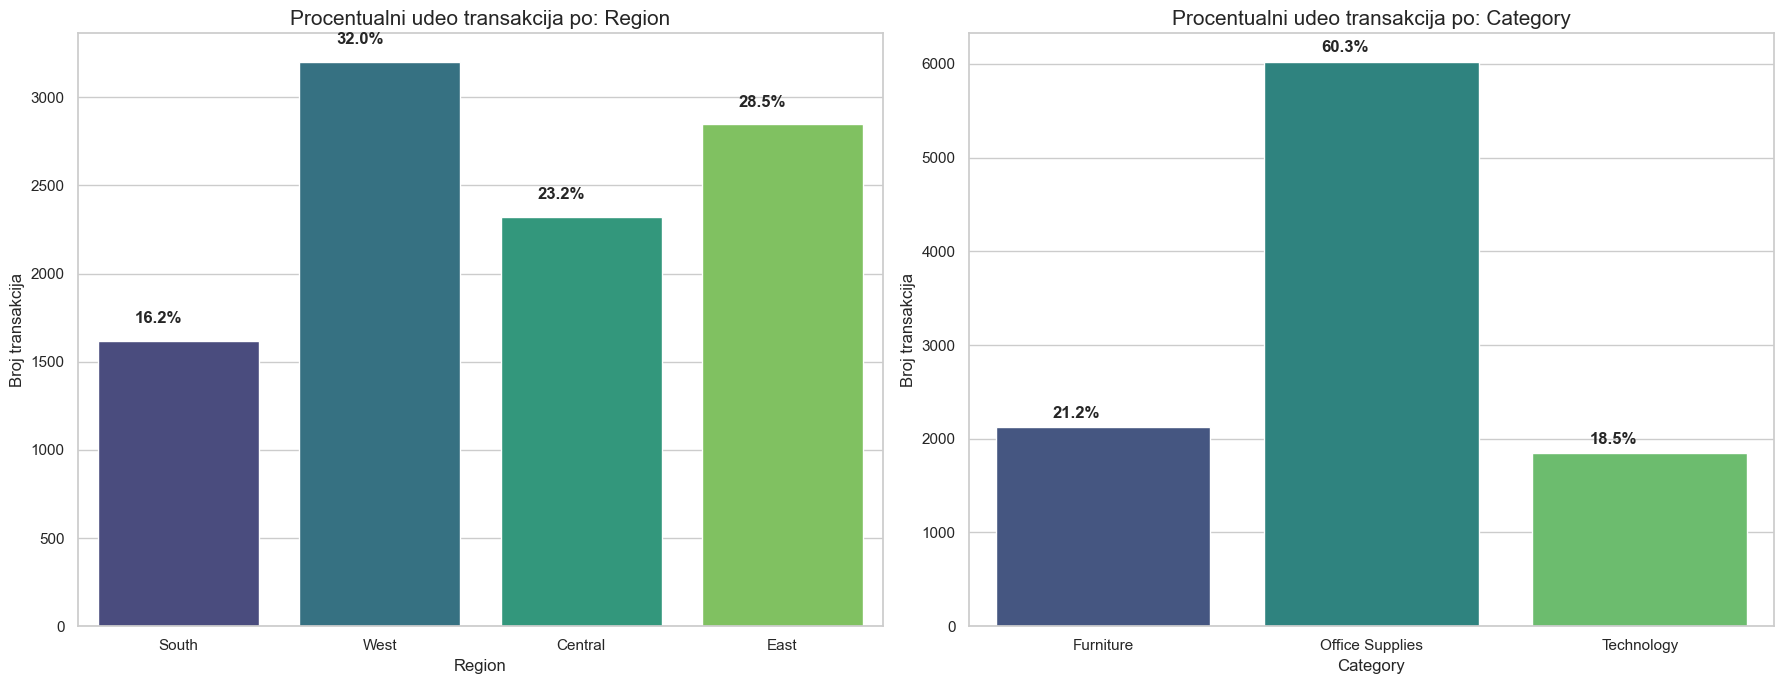

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
total = len(data)

attributes = ['Region', 'Category']

for i, attr in enumerate(attributes):
    ax = sns.countplot(x=attr, data=data, palette='viridis', ax=axes[i], hue=attr, legend=False)
    
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2 - 0.1  # Pozicioniranje teksta po X osi
        y = p.get_height() + (total * 0.01)     # Pozicioniranje teksta malo iznad stubića
        ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold', ha='center')

    axes[i].set_title(f'Procentualni udeo transakcija po: {attr}', fontsize=15)
    axes[i].set_ylabel('Broj transakcija')
    axes[i].set_xlabel(attr)

plt.tight_layout()
plt.show()

Mozemo da vidimo da iako je udeo prodaja tehnologije najmanji - ona prosecno donosi ubedljivo najvise profita. Takodje, bez obzira na to sto se Furniture prodaje izuzetno dobro - on ipak generise najmanje profita jer ima najvecih popusta u proseku. Office Supplies je najzastupljenija prodajna roba i generise najmanji Sales, verovatno zato sto su to najjeftiniji proizvodi, ali ipak generisu dobar profit (bolji od Furniture).
<br>Sto se tice Regiona, tu se vidi da, bez obzira sto je West najzastupljeniji, ima prosecno najmanji popust - znaci da najbolji profit nije samo proizvod zastupljenosti.

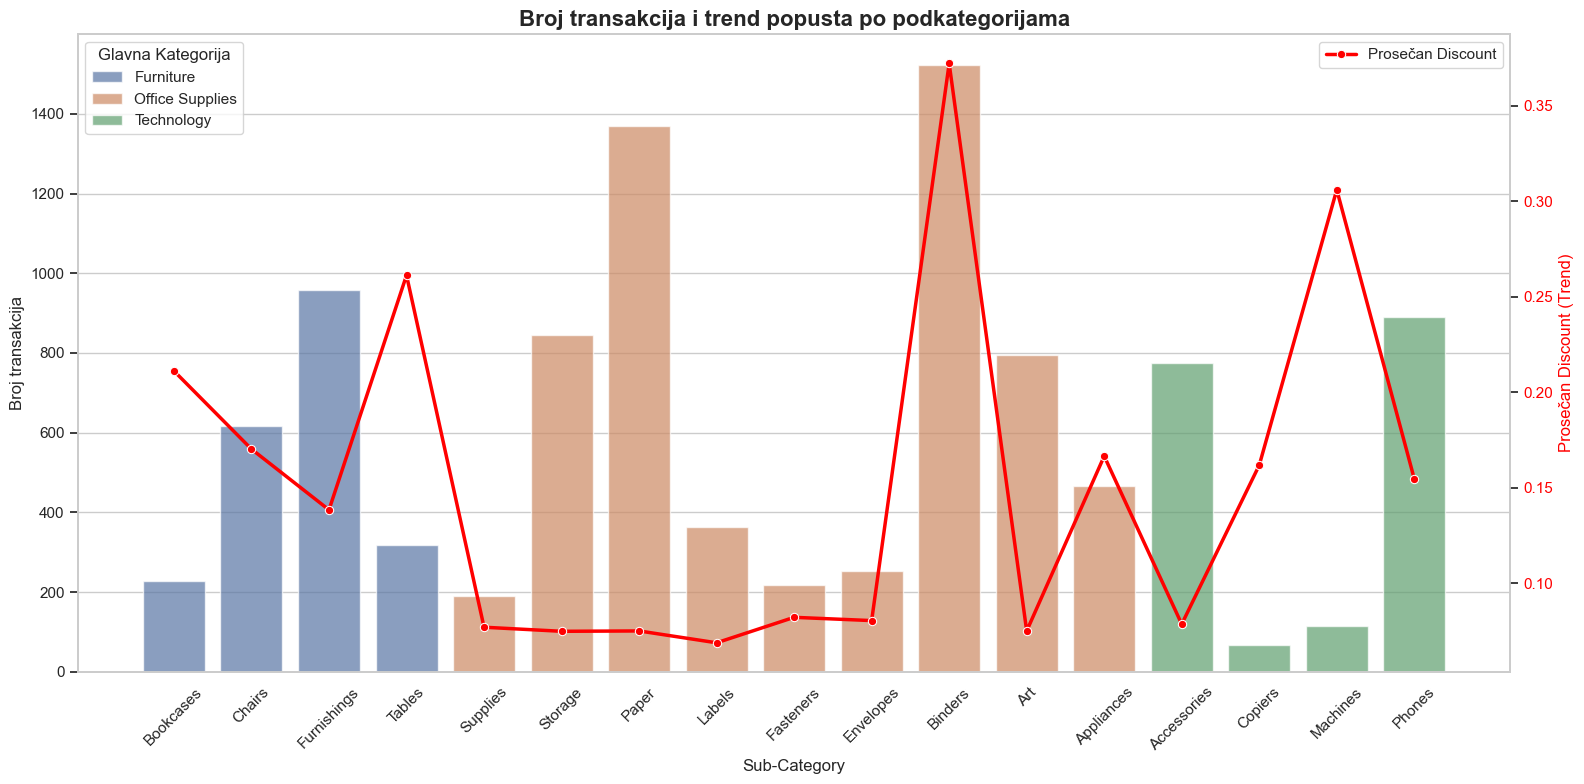

In [17]:
sub_cat_stats = data.groupby(['Category', 'Sub-Category']).agg(
    Count=('Sub-Category', 'count'),
    Avg_Discount=('Discount', 'mean')
).reset_index().sort_values('Category')

fig, ax1 = plt.subplots(figsize=(16, 8))

sns.barplot(
    x='Sub-Category', 
    y='Count', 
    hue='Category', 
    data=sub_cat_stats, 
    ax=ax1, 
    dodge=False, 
    alpha=0.7
)

ax1.set_title('Broj transakcija i trend popusta po podkategorijama', fontsize=16, fontweight='bold')
ax1.set_xlabel('Sub-Category', fontsize=12)
ax1.set_ylabel('Broj transakcija', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Glavna Kategorija', loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(
    x='Sub-Category', 
    y='Avg_Discount', 
    data=sub_cat_stats, 
    ax=ax2, 
    color='red', 
    marker='o', 
    linewidth=2.5, 
    label='Prosečan Discount',
    sort=False 
)

ax2.set_ylabel('Prosečan Discount (Trend)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False) 

plt.tight_layout()
plt.show()

Zarada na niskobudzetnim proizvodima koji se masovno prodaju.

Vidi se da Furniture prosecno pruza najvece popuste - pruza popuste i za proizvode koji se malo i koji se puno prodaju.
Sub-Category pruza prosecno najmanji i najveci popust za dva najprodavanija proizvoda, dok za ostale maltene ni nema popusta.
Technology pruza prosecno najvece popuste za prozivode koji se ne prodaju - sto je cudno, jer obicno se vise kupuju stvari koje su na vecem popustu. Ali treba uzeti u obzir da su u pitanju masine - proizvodi koji se redje kupuju inace. Mozda i razlog zasto technology pruza najveci profit je sto se za najprodavanije proizvode prosecno daju manji popusti.

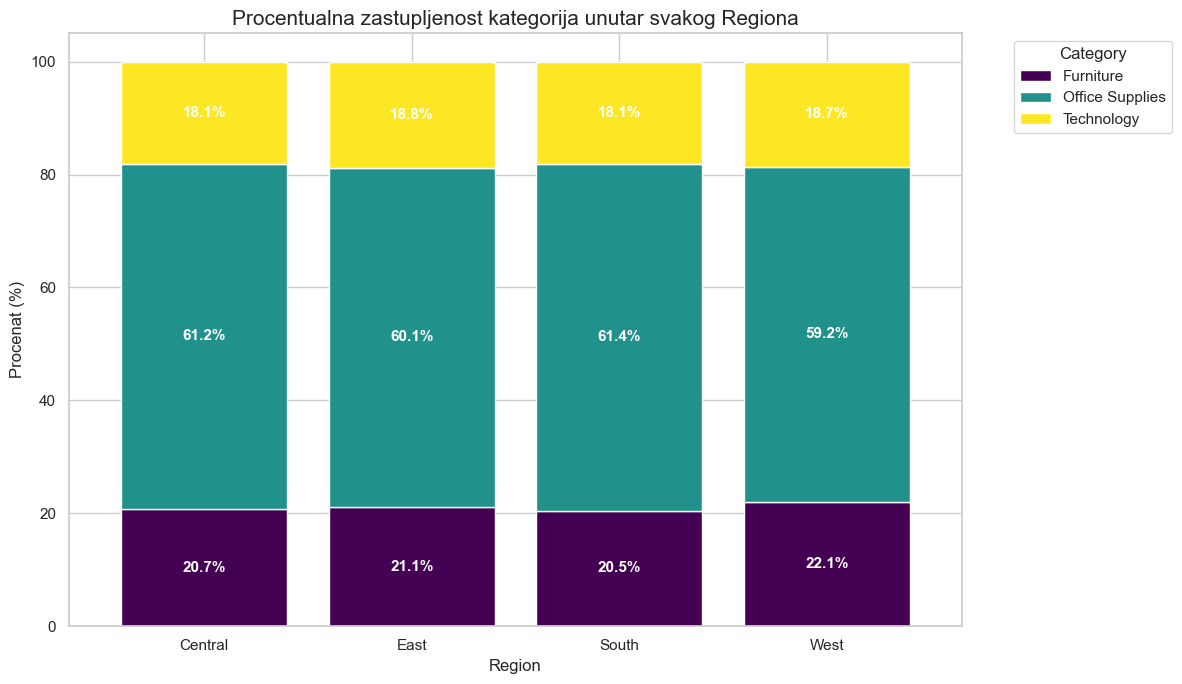

In [18]:
cross_tab = pd.crosstab(data['Region'], data['Category'])

cross_tab_prop = cross_tab.div(cross_tab.sum(1).astype(float), axis=0) * 100


ax = cross_tab_prop.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', width=0.8)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:  # Ispisujemo samo ako je procenat veći od nule
        x, y = p.get_xy() 
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Procentualna zastupljenost kategorija unutar svakog Regiona', fontsize=15)
plt.ylabel('Procenat (%)')
plt.xlabel('Region')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sve kategorije se ravnomerno prodaju u sva 4 regiona - nema uticaja prodajne robe na neefikasnost centralnog regiona.

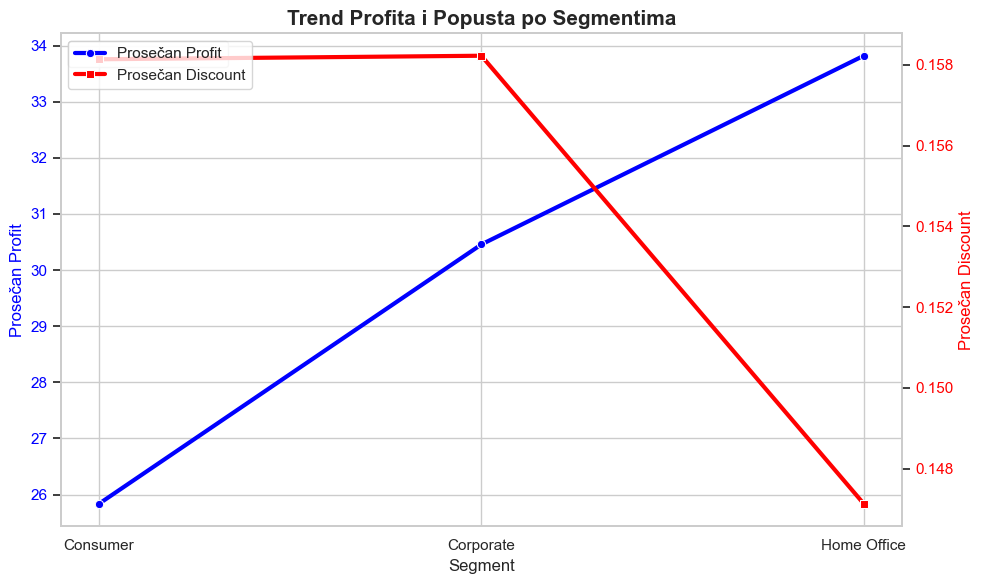

In [19]:
segment_stats = data.groupby('Segment').agg({
    'Profit': 'mean',
    'Discount': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.lineplot(x='Segment', y='Profit', data=segment_stats, ax=ax1, 
             color='blue', marker='o', linewidth=3, label='Prosečan Profit')
ax1.set_ylabel('Prosečan Profit', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Trend Profita i Popusta po Segmentima', fontsize=15, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x='Segment', y='Discount', data=segment_stats, ax=ax2, 
             color='red', marker='s', linewidth=3, label='Prosečan Discount')
ax2.set_ylabel('Prosečan Discount', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

ax2.grid(False)
plt.tight_layout()
plt.show()

In [20]:
segment_summary = data.groupby('Segment').agg({
    'Profit': ['mean'],
    'Discount': ['mean'],
    'Sales': 'mean',
    'Quantity': 'mean'
}).round(2)

segment_summary.columns = ['_'.join(col).strip() for col in segment_summary.columns.values]

print("Detaljna statistika po Segmentima:")
print(segment_summary)

Detaljna statistika po Segmentima:
             Profit_mean  Discount_mean  Sales_mean  Quantity_mean
Segment                                                           
Consumer           25.84           0.16      223.73           3.76
Corporate          30.46           0.16      233.82           3.84
Home Office        33.82           0.15      240.97           3.78


Vredsni narucioci:
1. Home Office
2. Corporate
3. Segment

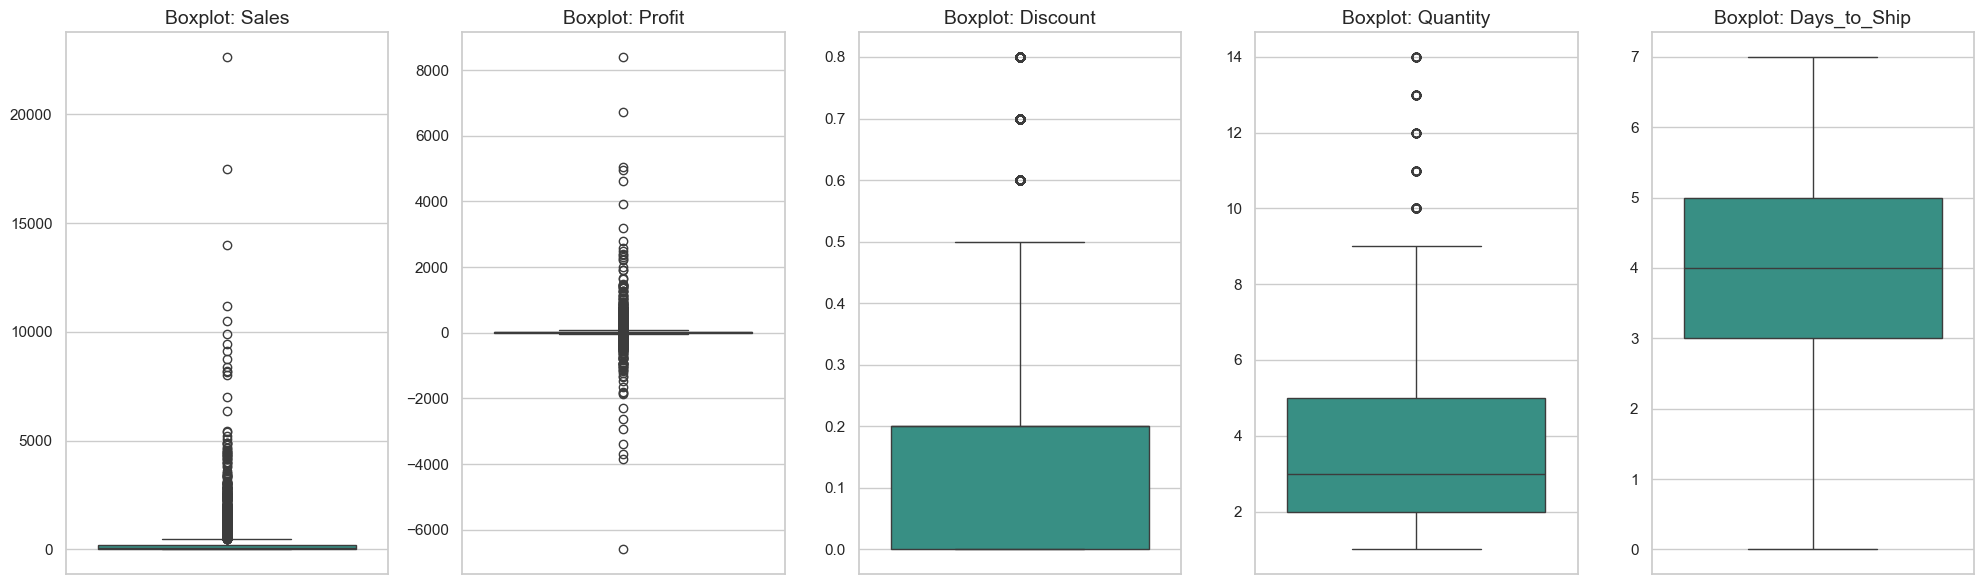

In [21]:
numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Days_to_Ship']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='#2a9d8f')
    axes[i].set_title(f'Boxplot: {col}', fontsize=14)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

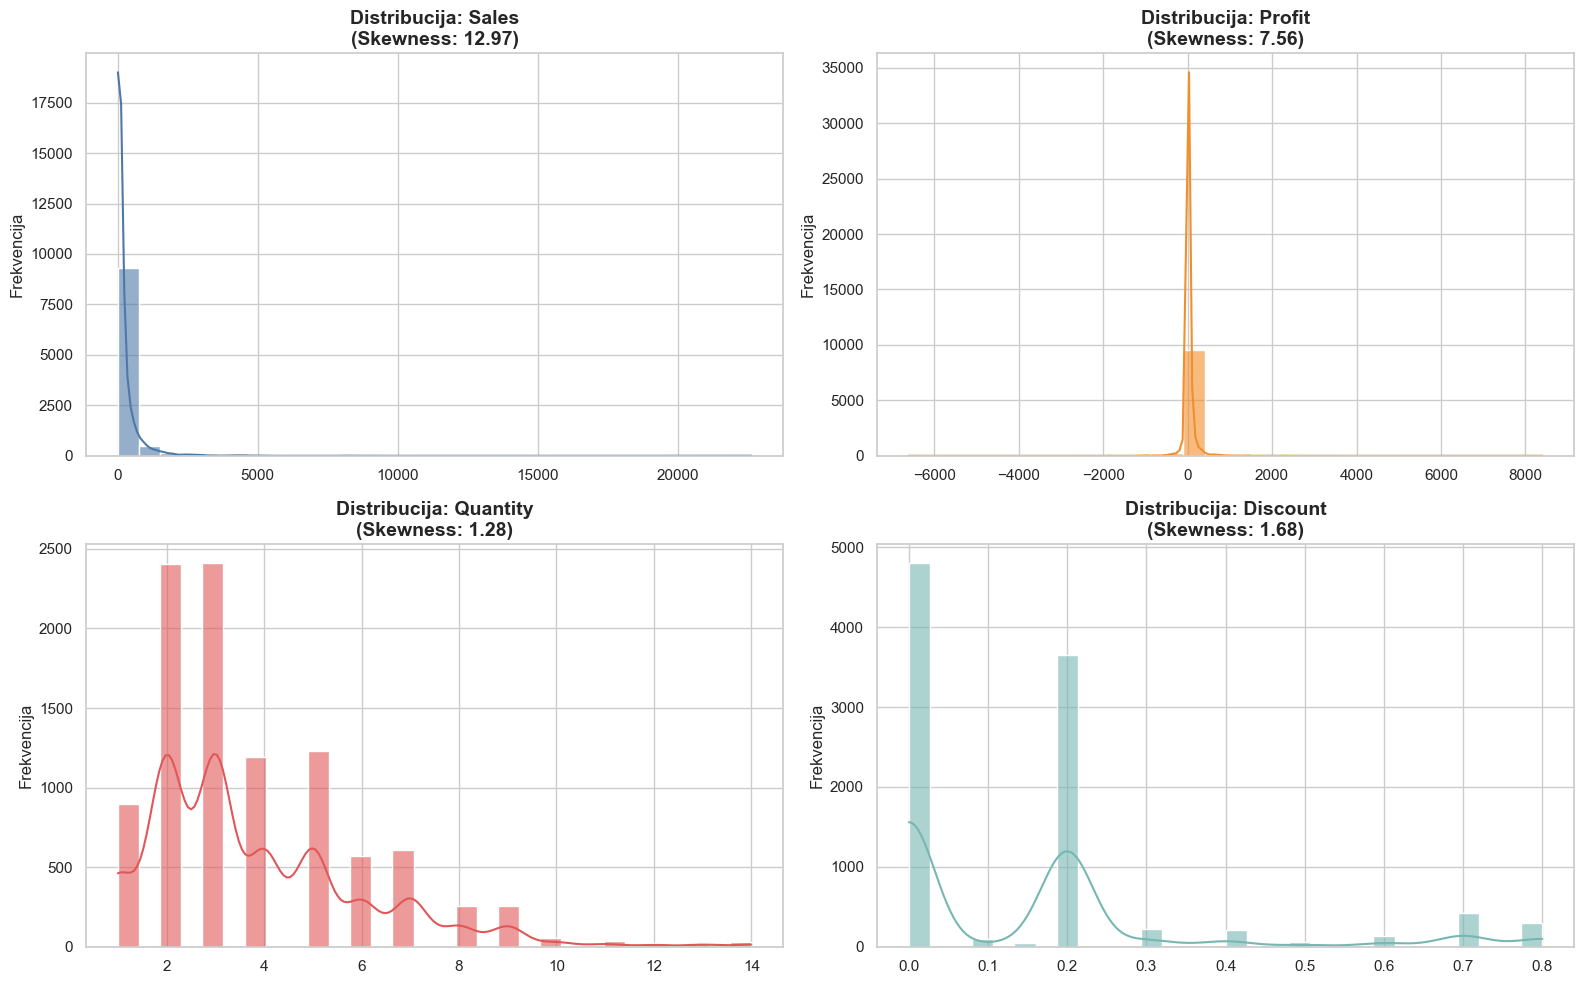

In [22]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

cols = ['Sales', 'Profit', 'Quantity', 'Discount']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    sns.histplot(data[col], kde=True, color=colors[i], bins=30, alpha=0.6)
    
    skew_val = data[col].skew()
    
    ax.set_title(f'Distribucija: {col}\n(Skewness: {skew_val:.2f})', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frekvencija')

plt.tight_layout()
plt.show()

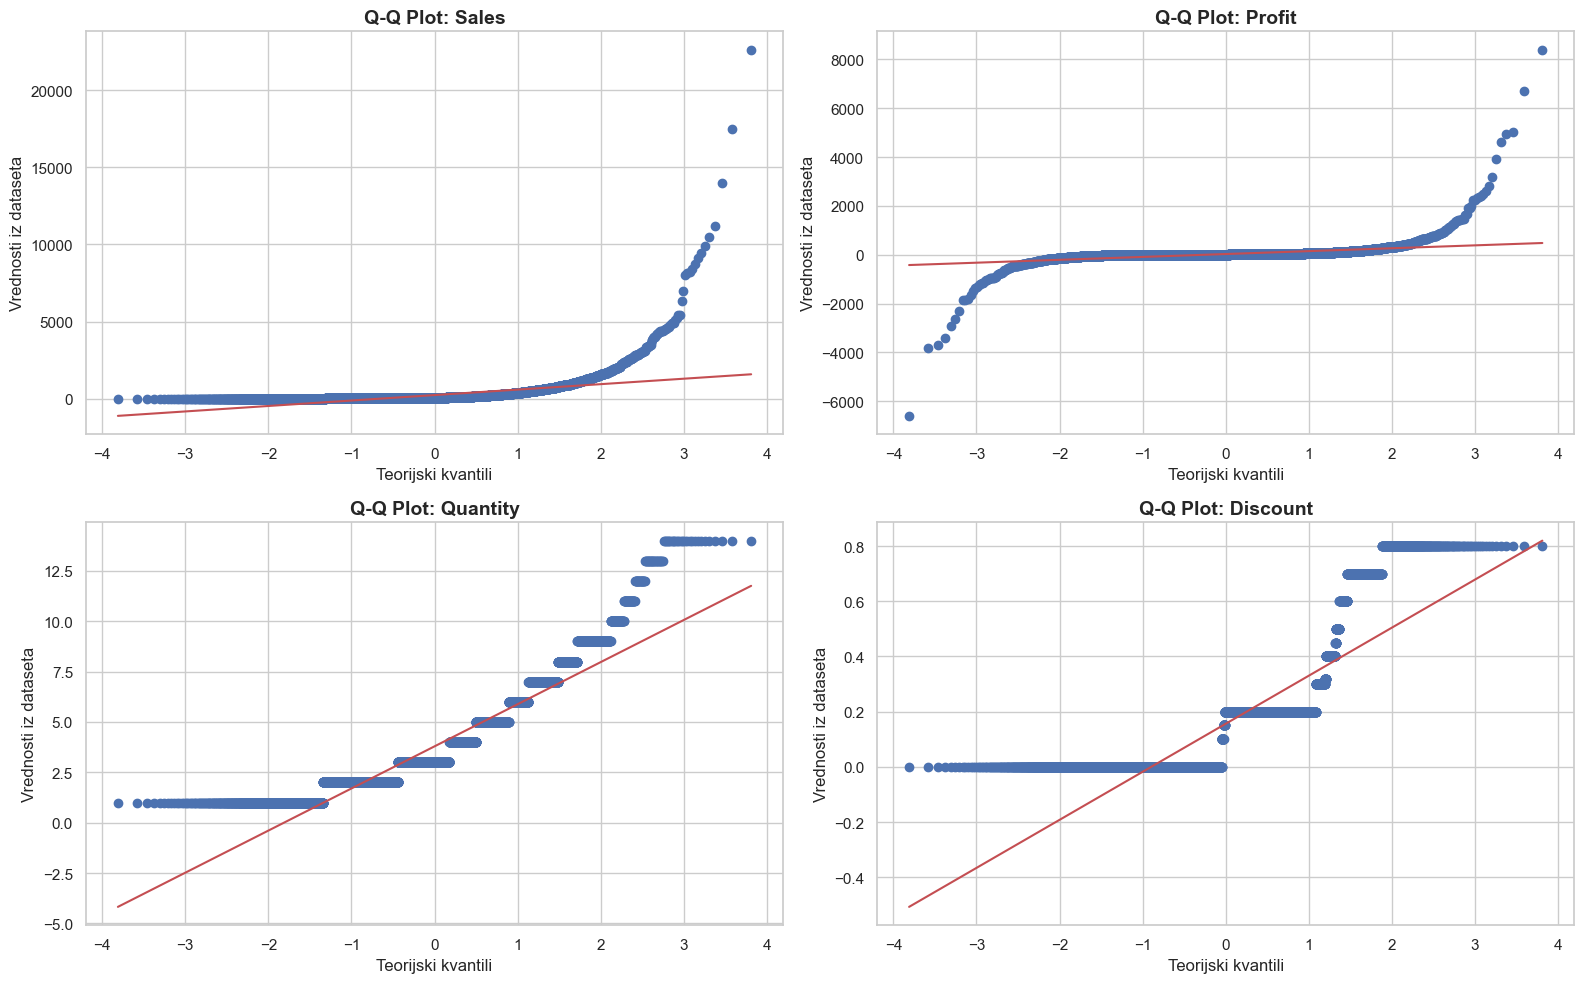

In [23]:
plt.figure(figsize=(16, 10))

cols = ['Sales', 'Profit', 'Quantity', 'Discount']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    stats.probplot(data[col], dist="norm", plot=plt)
    
    ax.set_title(f'Q-Q Plot: {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Teorijski kvantili')
    ax.set_ylabel('Vrednosti iz dataseta')

plt.tight_layout()
plt.show()

## Normalizacija i detektovanje outliera


Na osnovu Q-Q plotova i vrednosti Skewness koja je veca od 1, izvrsicu box-cox normalizaciju za sve sem za Profit, jer on moze imati i negativne vrednosti.

In [24]:
data_transactions = data.copy()

profit_min_abs = abs(data_transactions['Profit'].min()) + 1
data_transactions['Profit_trans'] = np.sign(data['Profit']) * np.power(np.abs(data['Profit']), 1/3)

for col in ['Sales', 'Quantity', 'Discount']:
    # stats.boxcox vraća (transformisan_niz, optimalni_lambda)
    data_transactions[f'{col}_trans'], _ = stats.boxcox(data_transactions[col] + 0.001)

new_stats = data_transactions[[f'{c}_trans' for c in ['Sales', 'Profit', 'Quantity', 'Discount']]].agg(['skew', 'kurtosis','mean','std','min']).T
print("Statistika nakon hibridne transformacije:")
print(new_stats)


Statistika nakon hibridne transformacije:
                    skew  kurtosis      mean       std        min
Sales_trans     0.016074 -0.583856  3.664132  1.335703  -0.826136
Profit_trans   -0.738572  3.095932  1.672131  2.881464 -18.757754
Quantity_trans -0.007714 -0.394632  1.256597  0.656240   0.001000
Discount_trans -0.022133 -1.914226 -3.873613  2.664029  -6.620804


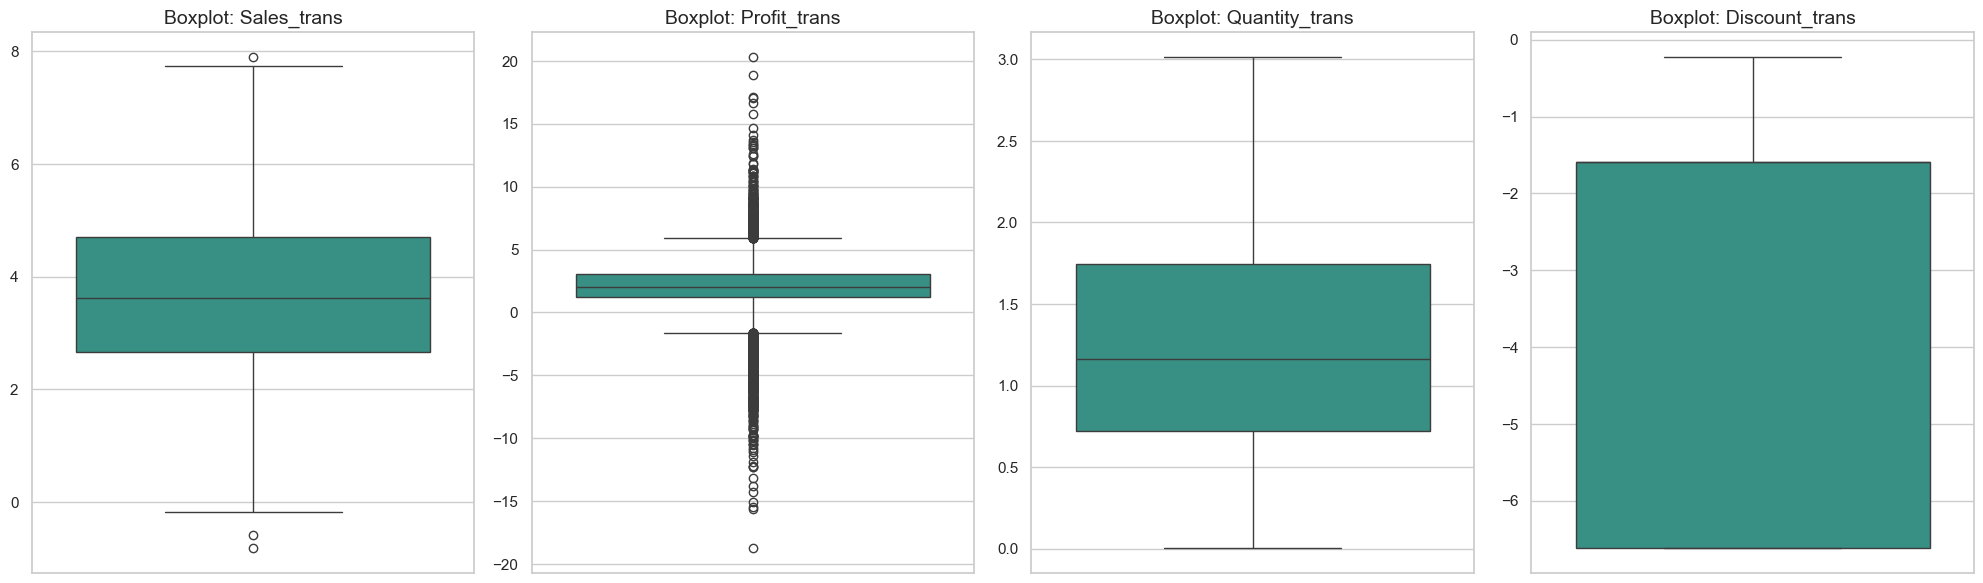

In [25]:
# Lista mora da sadrži nazive novih, transformisanih kolona
transformed_numeric_cols = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']

fig, axes = plt.subplots(1, len(transformed_numeric_cols), figsize=(20, 6))

for i, col in enumerate(transformed_numeric_cols):
    # Sada pozivamo kolone sa _trans sufiksom
    sns.boxplot(y=data_transactions[col], ax=axes[i], color='#2a9d8f')
    axes[i].set_title(f'Boxplot: {col}', fontsize=14)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

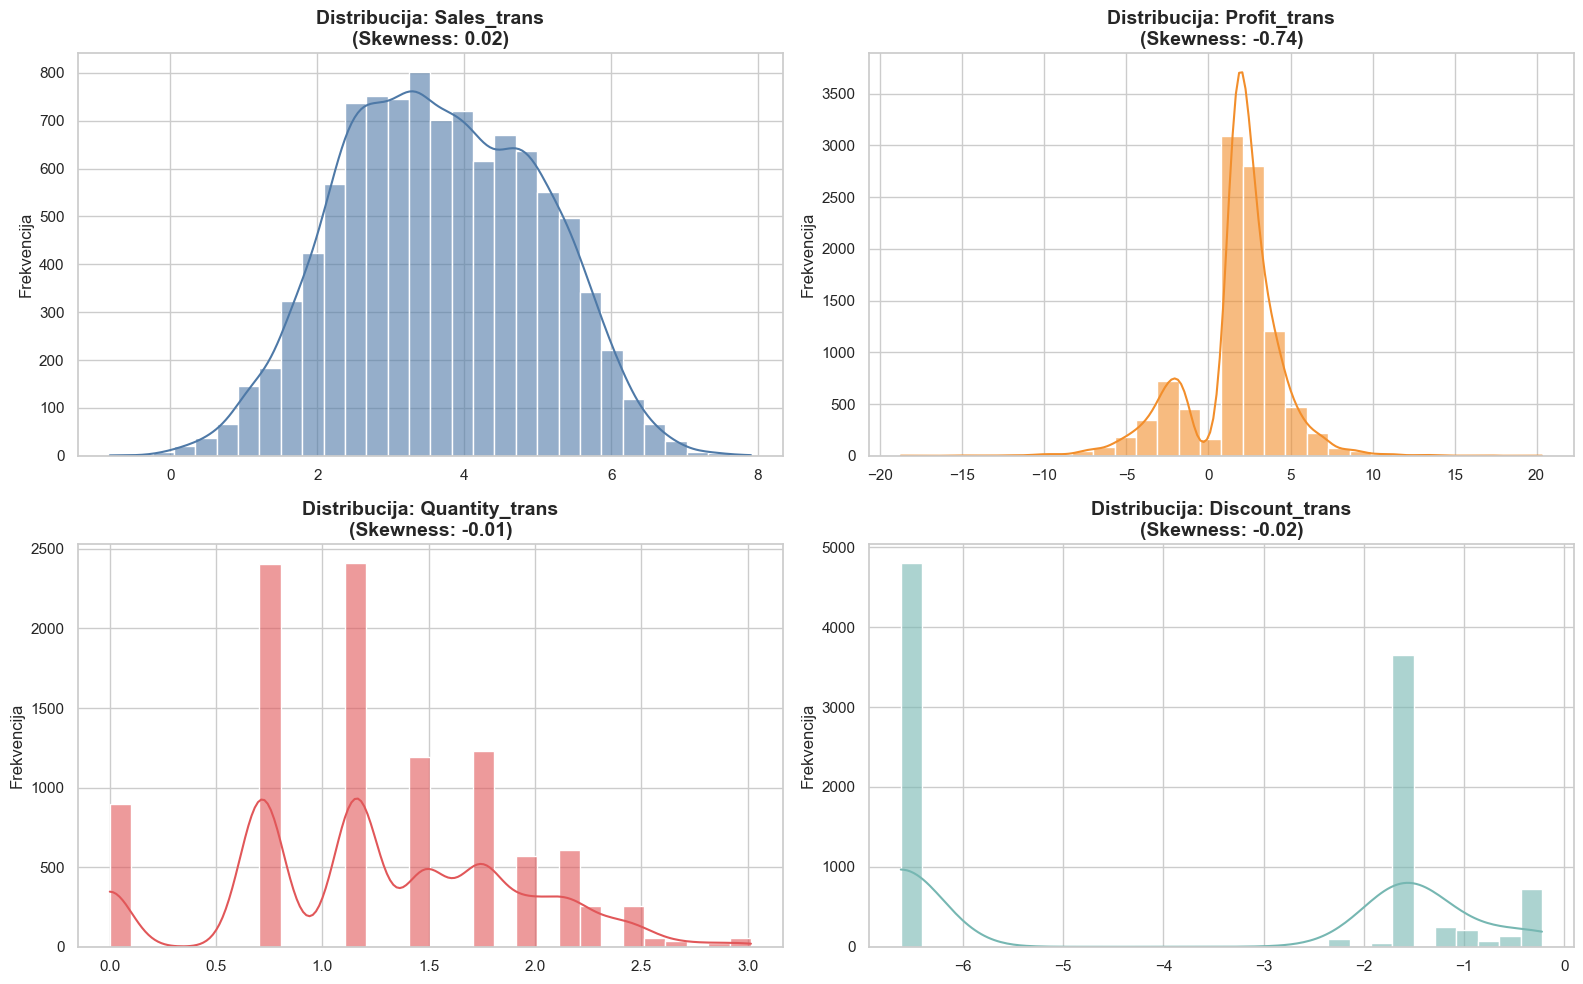

In [26]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

cols = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    sns.histplot(data_transactions[col], kde=True, color=colors[i], bins=30, alpha=0.6)
    
    skew_val = data_transactions[col].skew()
    
    ax.set_title(f'Distribucija: {col}\n(Skewness: {skew_val:.2f})', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frekvencija')

plt.tight_layout()
plt.show()

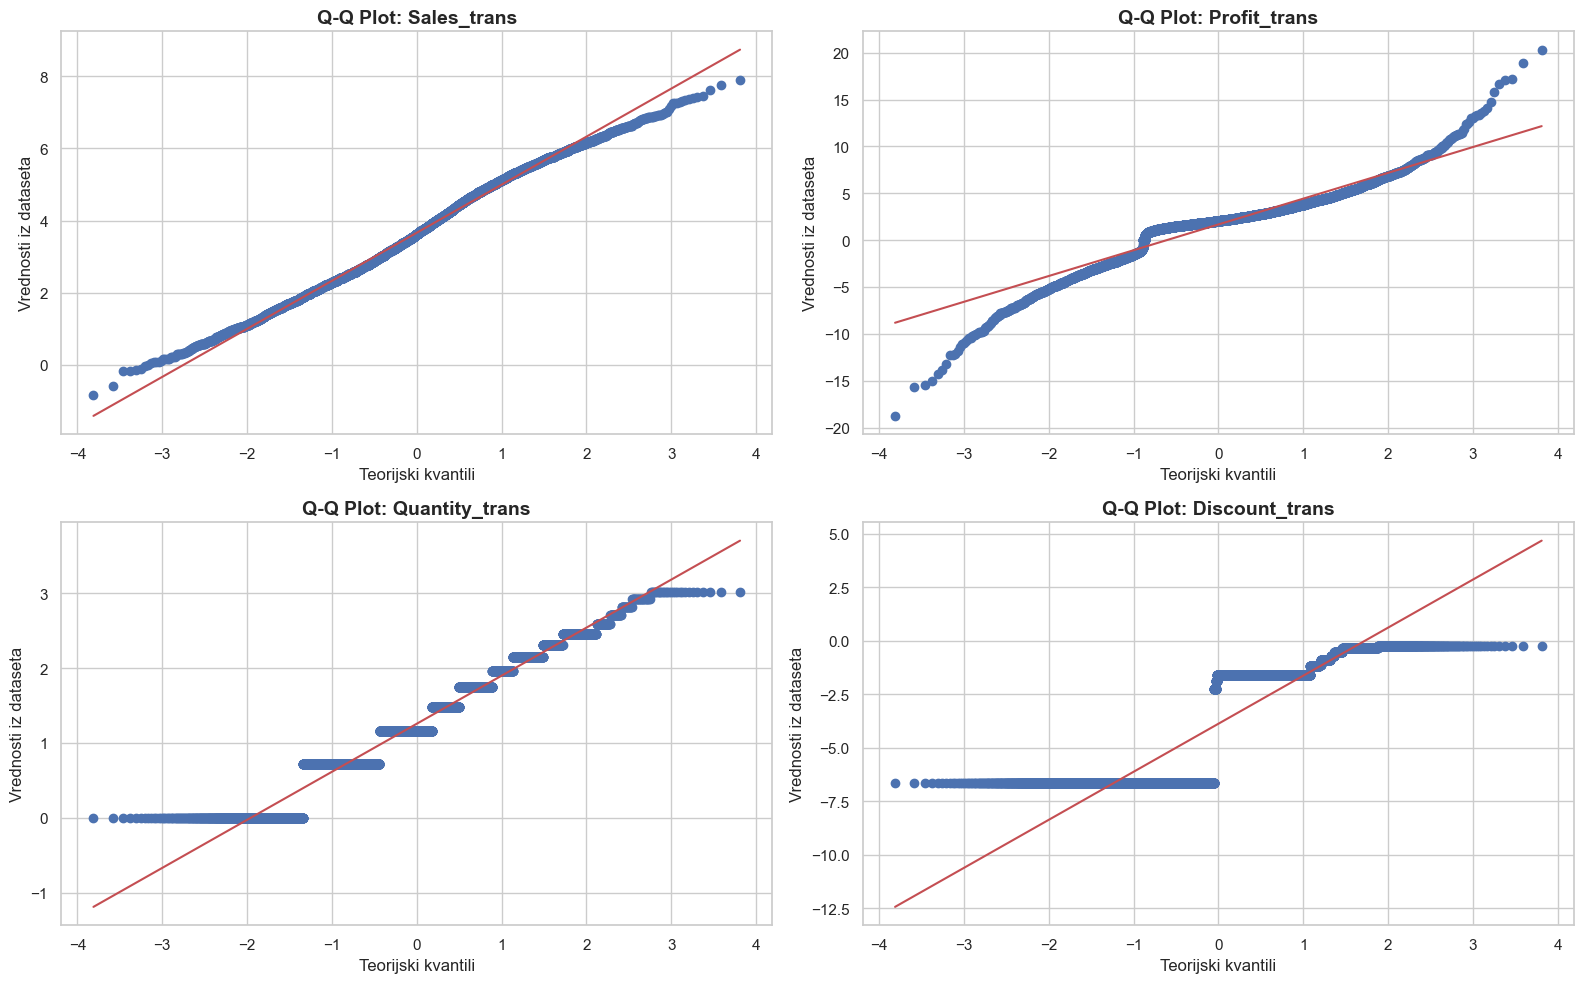

In [27]:
plt.figure(figsize=(16, 10))

cols = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    stats.probplot(data_transactions[col], dist="norm", plot=plt)
    
    ax.set_title(f'Q-Q Plot: {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Teorijski kvantili')
    ax.set_ylabel('Vrednosti iz dataseta')

plt.tight_layout()
plt.show()

Skewness je smanjen i podaci su sada normalnije distribuirani. Moze se videti da se broj 'realnih' outliera smanjio u koloni Sales, a u kolonama Discount i Quantity vise ne postoje outlieri - sto je i logicno, jer bez obzira sto u origalnom prikazu recimo quantity od 10 ili popust od 70% mogu delovati kao outlieri, to su ipak realne situacije koje se desavaju i imaju uticaja na prodaju i zato se ne trebaju izbacivati. Profit je uspeo da zadrzi visok kurtosis i standardnu devijaciju (u odnosu na druge) što je i očekivano jer gubici i visoki profiti imaju specifičnu težinu koja treba da ostane vidljiva u klasterizaciji, a profit moze da bude i negativan - to se vidi postojanjem dva centra distribucije, jednog negativnog i jednog pozitivnog.

## Resavanje outliera


Zbog prethodno pomenutog razloga, sto su sve situacije realne i uticu na prodaju, odlucio sam se za Winsorizing.

Capping završen selektivno za Sales i Profit na 1% i 99% percentila.


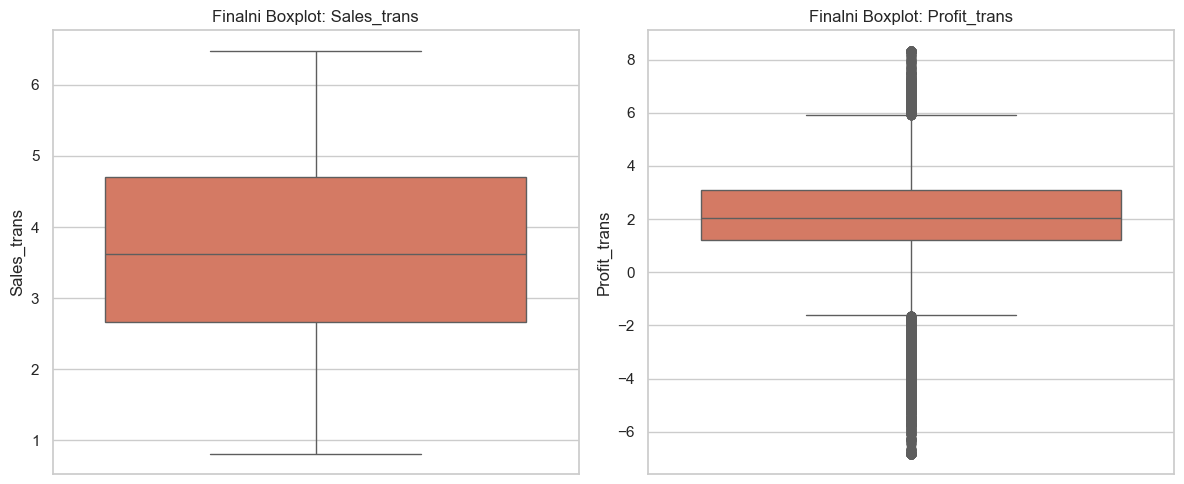

In [28]:
data_final_prep = data_transactions.copy()

cols_to_cap = ['Sales_trans', 'Profit_trans']

for col in cols_to_cap:
    lower_limit = data_final_prep[col].quantile(0.01)
    upper_limit = data_final_prep[col].quantile(0.99)
    
    data_final_prep[col] = data_final_prep[col].clip(lower_limit, upper_limit)

print("Capping završen selektivno za Sales i Profit na 1% i 99% percentila.")

plt.figure(figsize=(12, 5))
for i, col in enumerate(cols_to_cap):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=data_final_prep[col], color='#e76f51')
    plt.title(f'Finalni Boxplot: {col}')

plt.tight_layout()
plt.show()

Moze se po y-osi videti da su se outlieri sabili.

In [29]:
data_final_prep.head()

,Order ID,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,...,Discount,Profit,Month,Year,Days_to_Ship,Order_Season,Profit_trans,Sales_trans,Quantity_trans,Discount_trans
0,CA-2016-152156,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,...,0.00,41.9136,11,2016,3,Fall,3.473641,4.866320,0.718027,-6.620804
1,CA-2016-152156,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,...,0.00,219.5820,11,2016,3,Fall,6.032985,5.626647,1.160976,-6.620804
2,CA-2016-138688,Second Class,DV-13045,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,...,0.00,6.8714,6,2016,4,Summer,1.901144,2.511892,0.718027,-6.620804
3,US-2015-108966,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,...,0.45,-383.0310,10,2015,7,Fall,-6.834662,5.819182,1.745030,-0.792378
4,US-2015-108966,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,...,0.20,2.5164,10,2015,7,Fall,1.360170,2.880311,0.718027,-1.588630


## Redukcija dimenzionalnosti

In [30]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

result = cramers_v(data['State'], data['City'])
print(f"Cramér's V povezanost između State i City: {result:.4f}")

Cramér's V povezanost između State i City: 0.8758


In [31]:
result = cramers_v(data['Category'], data['Sub-Category'])
print(f"Cramér's V povezanost između Category i Sub-Category: {result:.4f}")

Cramér's V povezanost između Category i Sub-Category: 0.9993


In [32]:
result = cramers_v(data['Product Name'], data['Sub-Category'])
print(f"Cramér's V povezanost između Product Name i Sub-Category: {result:.4f}")

Cramér's V povezanost između Product Name i Sub-Category: 0.9035


In [33]:
result = cramers_v(data['Product Name'], data['Category'])
print(f"Cramér's V povezanost između Product Name i Category: {result:.4f}")

Cramér's V povezanost između Product Name i Category: 0.9028


In [34]:
result = cramers_v(data['State'], data['Region'])
print(f"Cramér's V povezanost između State i Region: {result:.4f}")

Cramér's V povezanost između State i Region: 0.9977


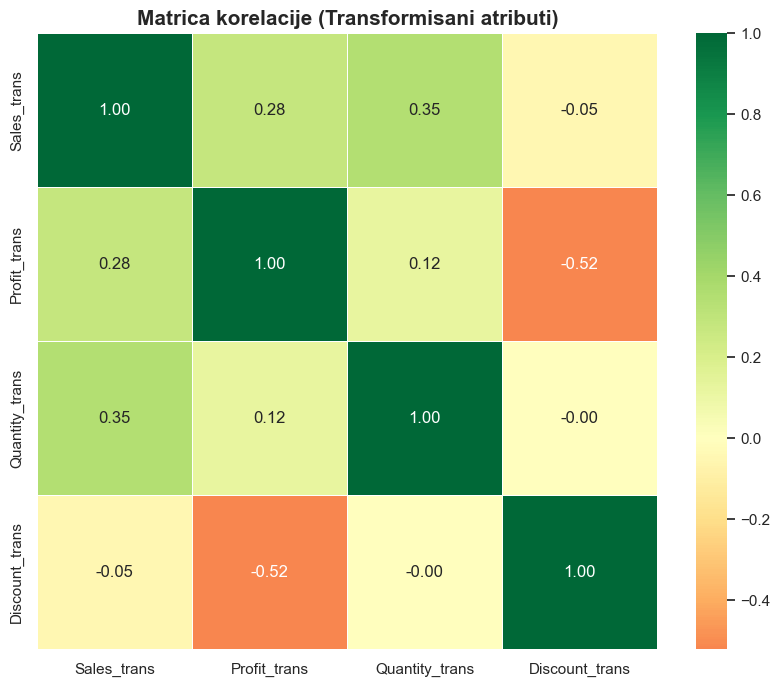

In [35]:
numerical_columns = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']

corr_matrix = data_final_prep[numerical_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='RdYlGn', 
    linewidths=0.5,
    center=0
)

plt.title('Matrica korelacije (Transformisani atributi)', fontsize=15, fontweight='bold')
plt.show()

Vidi se jaka koleracija, izmedju Discounta i Profita (- 0.51) - sto je discount veci to je profit manji

In [36]:
data_final_prep = data_final_prep.drop(['Order ID','Customer ID','Ship Mode','City','State','Product ID','Sub-Category','Discount','Profit','Month','Year','Order_Season','Quantity','Sales','Product Name'], axis = 1)

## Enkodiranje kateogorickih kolona

In [37]:
segment_map = {
    'Home Office': 2,
    'Corporate': 1,
    'Consumer': 0
}

data_final_prep['Segment_enc'] = data_final_prep['Segment'].map(segment_map)

print("Provera enkodiranja u data_final_prep:")
print(data_final_prep[['Segment', 'Segment_enc']].drop_duplicates().sort_values('Segment_enc', ascending=False))

Provera enkodiranja u data_final_prep:
        Segment  Segment_enc
14  Home Office            2
2     Corporate            1
0      Consumer            0


In [38]:
data_final_prep = data_final_prep.drop(['Segment'], axis = 1)

In [39]:
data_final_prep.head()


,Region,Category,Days_to_Ship,Profit_trans,Sales_trans,Quantity_trans,Discount_trans,Segment_enc
0,South,Furniture,3,3.473641,4.866320,0.718027,-6.620804,0
1,South,Furniture,3,6.032985,5.626647,1.160976,-6.620804,0
2,West,Office Supplies,4,1.901144,2.511892,0.718027,-6.620804,1
3,South,Furniture,7,-6.834662,5.819182,1.745030,-0.792378,0
4,South,Office Supplies,7,1.360170,2.880311,0.718027,-1.588630,0


In [40]:
region_map = {
    'Central': 0,
    'South': 1,
    'East': 2,
    'West': 3
}

category_map = {
    'Furniture': 0,
    'Office Supplies': 1,
    'Technology': 2
}

data_final_prep['Region_enc'] = data_final_prep['Region'].map(region_map)
data_final_prep['Category_enc'] = data_final_prep['Category'].map(category_map)



In [41]:
data_final_prep = data_final_prep.drop(['Region','Category'], axis = 1)


## Skaliranje finalnog dataseta

In [42]:
scaler = RobustScaler()
data_final_prep_scaled = scaler.fit_transform(data_final_prep)

data_final_prep_scaled = pd.DataFrame(
    data_final_prep_scaled, 
    columns=data_final_prep.columns
)


data_final_prep_scaled.head()

,Days_to_Ship,Profit_trans,Sales_trans,Quantity_trans,Discount_trans,Segment_enc,Region_enc,Category_enc
0,-0.5,0.753112,0.607557,-0.431302,-1.000000,0.0,-0.5,-1.0
1,-0.5,2.110894,0.980313,0.000000,-1.000000,0.0,-0.5,-1.0
2,0.0,-0.081128,-0.546719,-0.431302,-1.000000,1.0,0.5,0.0
3,1.5,-4.715646,1.074705,0.568698,0.158232,0.0,-0.5,-1.0
4,1.5,-0.368126,-0.366099,-0.431302,0.000000,0.0,-0.5,0.0


Sada ocisceni i transformisani skup podataka sadrzi logisticki faktor, finansijski faktor i biznis faktor.

## Nalazenje broja K

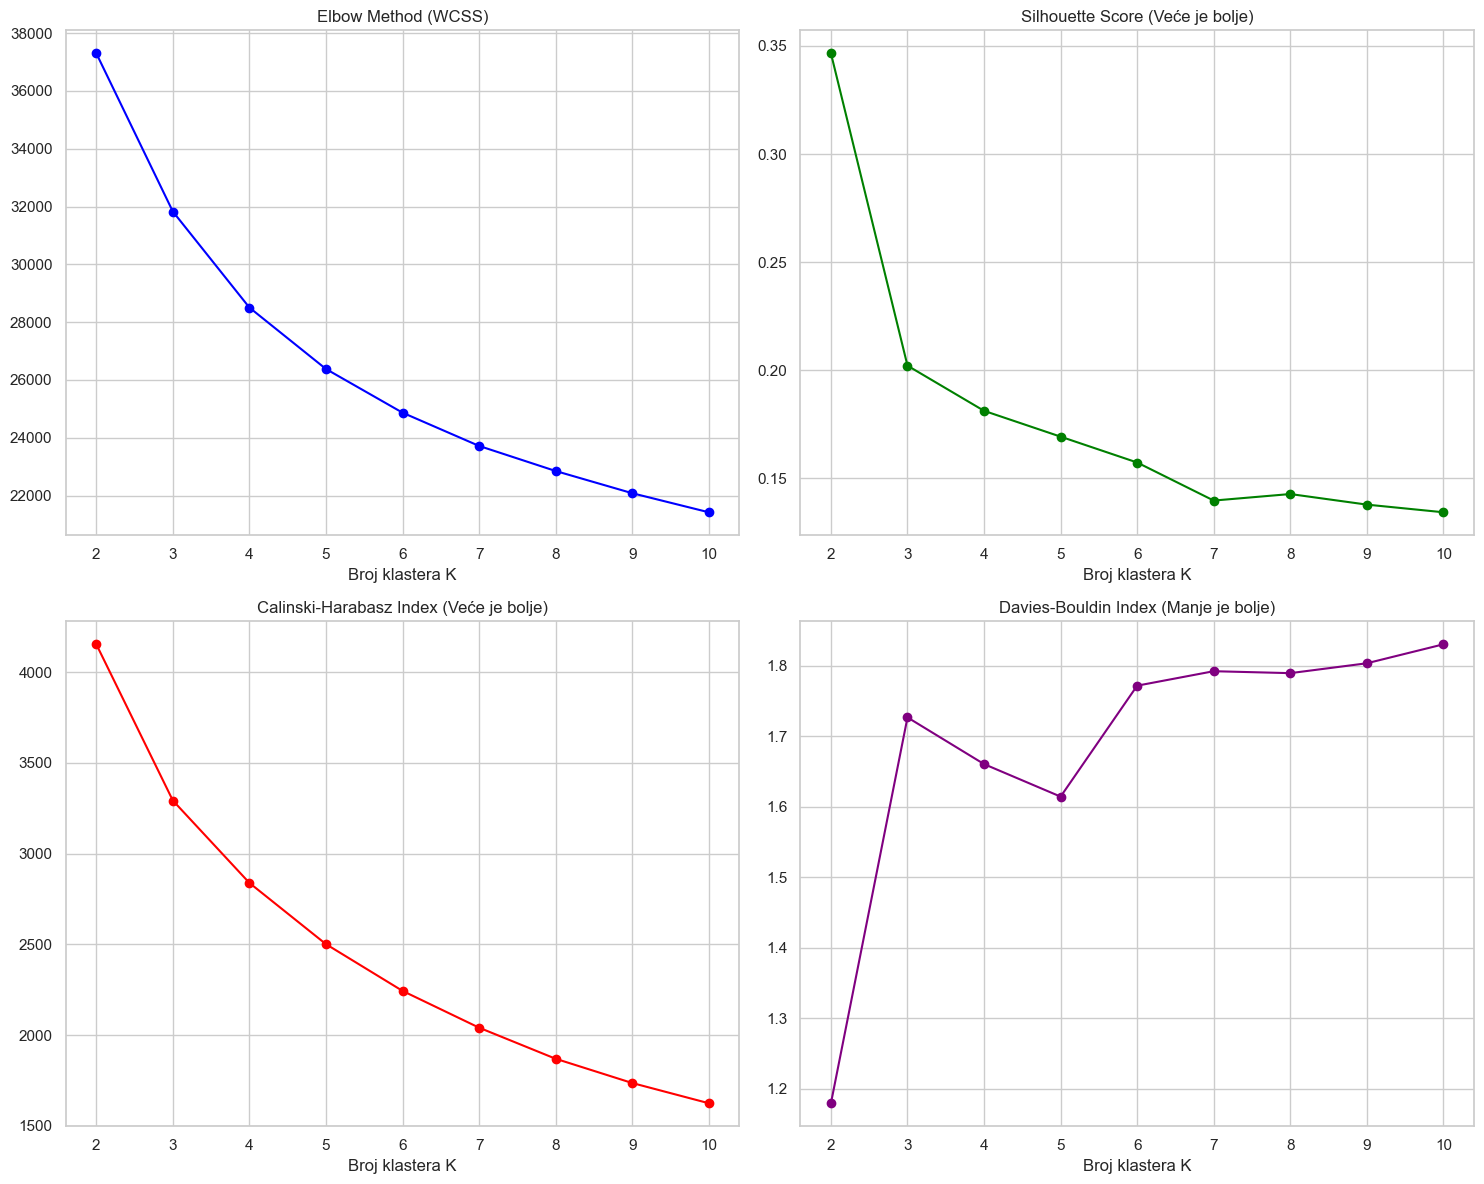

In [43]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

wcss = []
silhouette_avg = []
calinski_harabasz = []
davies_bouldin = []
k_range = range(2, 11) 


for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_final_prep_scaled)
    
    # 1. Elbow (Inertia/WCSS)
    wcss.append(kmeans.inertia_)
    
    # 2. Silhouette Score (Idealno: bliže 1)
    silhouette_avg.append(silhouette_score(data_final_prep_scaled, labels))
    
    # 3. Calinski-Harabasz (Idealno: veća vrednost)
    calinski_harabasz.append(calinski_harabasz_score(data_final_prep_scaled, labels))
    
    # 4. Davies-Bouldin (Idealno: manja vrednost bliža 0)
    davies_bouldin.append(davies_bouldin_score(data_final_prep_scaled, labels))

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Elbow Method
axs[0, 0].plot(range(2, 11), wcss, marker='o', color='blue')
axs[0, 0].set_title('Elbow Method (WCSS)')
axs[0, 0].set_xlabel('Broj klastera K')

# Silhouette Score
axs[0, 1].plot(k_range, silhouette_avg, marker='o', color='green')
axs[0, 1].set_title('Silhouette Score (Veće je bolje)')
axs[0, 1].set_xlabel('Broj klastera K')

# Calinski-Harabasz
axs[1, 0].plot(k_range, calinski_harabasz, marker='o', color='red')
axs[1, 0].set_title('Calinski-Harabasz Index (Veće je bolje)')
axs[1, 0].set_xlabel('Broj klastera K')

# Davies-Bouldin
axs[1, 1].plot(k_range, davies_bouldin, marker='o', color='purple')
axs[1, 1].set_title('Davies-Bouldin Index (Manje je bolje)')
axs[1, 1].set_xlabel('Broj klastera K')

plt.tight_layout()
plt.show()

Iako svi rezultati ukazuju da je broj 2 najbolji, ipak smatram da je zbog prethodno vizuelno uocenih razlika K=3 najoptimalniji izbor. Ipak, vizuelizovacu kasnije sva 3 slucajeva kako bih video kako izgledaju ti klasteri.

## Klasterizacija

In [44]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.cluster import HDBSCAN

kmeans = KMeans(n_clusters=3, random_state=17, n_init=10)
data_final_prep['KMeans_Labels'] = kmeans.fit_predict(data_final_prep_scaled)

hierarchical = AgglomerativeClustering(n_clusters=3)
data_final_prep['Hierarchical_Labels'] = hierarchical.fit_predict(data_final_prep_scaled)


hdbscan = HDBSCAN(min_cluster_size=30, min_samples=10, store_centers='centroid')
data_final_prep['HDBSCAN_Labels'] = hdbscan.fit_predict(data_final_prep_scaled)



In [45]:
data['KMeans_Labels'] = data_final_prep['KMeans_Labels']
data['Hierarchical_Labels'] = data_final_prep['Hierarchical_Labels']
data['HDBSCAN_Labels'] = data_final_prep['HDBSCAN_Labels']

def get_real_profile(df, label_col):
    
    return df.groupby(label_col).agg({
        'Profit': 'mean',
        'Sales': 'mean',
        'Discount': 'mean',
        'Quantity': 'mean',
        'Order ID': 'count' # Broj transakcija
    }).rename(columns={'Order ID': 'Count'}).round(2)

print("--- K-MEANS: REALNI PROFIL ---")
print(get_real_profile(data, 'KMeans_Labels'))

print("\n--- HIJERARHIJSKI: REALNI PROFIL ---")
print(get_real_profile(data, 'Hierarchical_Labels'))

print("\n--- HDBSCAN: REALNI PROFIL ---")
print(get_real_profile(data, 'HDBSCAN_Labels'))

--- K-MEANS: REALNI PROFIL ---
               Profit   Sales  Discount  Quantity  Count
KMeans_Labels                                           
0              -83.05  254.56      0.48      3.78   1880
1                9.64   48.76      0.09      3.23   5502
2              149.11  593.55      0.07      4.98   2612

--- HIJERARHIJSKI: REALNI PROFIL ---
                     Profit    Sales  Discount  Quantity  Count
Hierarchical_Labels                                            
0                     26.23   136.19      0.08      3.65   7360
1                    -83.23   252.47      0.48      3.76   1876
2                    329.09  1083.40      0.05      5.19    758

--- HDBSCAN: REALNI PROFIL ---
                Profit   Sales  Discount  Quantity  Count
HDBSCAN_Labels                                           
-1               57.80  508.49      0.20      4.31   2745
 0              -46.82  293.20      0.32      3.22     32
 1               18.06   73.50      0.03      3.19     90
 2  

K-Means: <br>
Lable 0: veliki popust/puno prodaja/negativan profit - 18% uzoraka - ovo su transakcije koje ne smeju da se ponavljaju jer ne doprinose radu firme. <br>
Lable 1: mali popust/malo prodaja/mali profit - 55% uzoraka - ovo su najstandardnije regularne prodaje kojih ima najvise. <br>
Lable 2: mali popust/mnogo prodaja/veliki profit - 26% uzoraka - ovo su transakcije na kojima je potrebno raditi kako bi ih bilo sto vise jer doprinose povecanju profita, i to bez popusta. <br>
<br>
<p>
    Hierarchical: <br>
    Lable 0: mali popust/srednja prodaja/mala zarada - 74% uzoraka - ovo su regularne transakcije (K-Means - Lable1) <br>
    Lable 1: veliki popust/puno prodaja/negativan profit - 18% - ovo su transakcije koje zbog velikog popusta prouzrokuju negativan profit (K-Means - Lable0)<br> 
    Lable 2: mali popust/mnogo prodaja/veliki profit - 8% - ovo su transakcije koje najvise doprinose zaradi (K-Means - Lable2) <br>
</p>

<p>
    HDBSCAN: <br>
    Dobio sam 25 klastera i outlier klaster, sto je neiterpretabilno.    
</p>

NOTES:
Kad kazem mnogo ili puno, razlikujem ih tako sto je mnogo > puno.
K-Means i Hierarchical su nasli relativno slicne (iste) klastere po karakteristikama, sa razlikom u distribuciji.
Zanimljivo je da su i K-Means i hijerarhijsko izdvojili isti klaster od 18% uzoraka (ne mora da znaci da su i bas isti uzorci).

### Novi test za HDBSCAN:

In [46]:
hdbscan = HDBSCAN(min_cluster_size=400, min_samples=50, cluster_selection_epsilon=0.1, store_centers='centroid')

data_final_prep['HDBSCAN_Labels_V2'] = hdbscan.fit_predict(data_final_prep_scaled)

data['HDBSCAN_Labels_V2'] = data_final_prep['HDBSCAN_Labels_V2']



In [47]:
print("\n--- HDBSCAN_V2: REALNI PROFIL ---")
print(get_real_profile(data, 'HDBSCAN_Labels_V2'))


--- HDBSCAN_V2: REALNI PROFIL ---
                   Profit   Sales  Discount  Quantity  Count
HDBSCAN_Labels_V2                                           
-1                  34.79  306.34      0.19      3.87   7084
 0                  17.47   52.40      0.00      3.64   1277
 1                  12.90   39.59      0.08      3.56    898
 2                   8.24   33.45      0.20      3.56    735


HDBSCAN:<br>
Lable 0 i 1: Poprilicno isti klasteri po svim parametrima, bez popusta/mala prodaja/mala zarada - podsecaju na one regularne korisnike iz K-Means i Hijerarhijskog. <br>
Lable 2: mali popust/mala prodaja/mala zarada - ovo je neka nova grupa transakcija koja vrlo lako moze da se prikljuci predhodnim dveju labela. <br>
Lable -1 outlieri: Najveci broj transakcija je klasterizovao kao outliere, mali popust/puno prodaja/mala zarada. Na osnovu prosecnih vrednosti i count-a, rekao bih da je algoritam ovde smestio sve one pozitivne i negativne visoke vrednosti za profit, pa iz tog razloga su prosecne vrednosti ovako umerene.

------------------------

Razmisljao sam o poredjenu metoda i Dunn Indexom, ali zbog velikog broja ekstremnih vrednosti odustao sam.

-------------------

### MeanShift algoritam:

In [48]:
from sklearn.cluster import MeanShift, estimate_bandwidth

ms = MeanShift(bandwidth=1.50, bin_seeding=True)
data['MeanShift_Labels'] = ms.fit_predict(data_final_prep_scaled)

def get_ms_profile(df, label_col):
    return df.groupby(label_col).agg({
        'Profit': 'mean',
        'Sales': 'mean',
        'Discount': 'mean',
        'Order ID': 'count'
    }).rename(columns={'Order ID': 'Count'}).round(2)

print("\n--- MEANSHIFT (DENCLUE logika): REALNI PROFIL ---")
print(get_ms_profile(data, 'MeanShift_Labels'))


--- MEANSHIFT (DENCLUE logika): REALNI PROFIL ---
                  Profit   Sales  Discount  Count
MeanShift_Labels                                 
0                  55.12  226.71      0.08   8023
1                 -12.32   45.10      0.55    898
2                -150.80  451.45      0.41    955
3                  -6.68   56.68      0.27    118


Lable 0: nizak popust/puno prodaja/solidan profit - ovo je opis regularnih transakcija, a algoritam je uspeo da ih klasterizuje cak 80%. <br>
Ostale klastere je algoritam svrstavao kao stetne kupovine i cak ih je dekompozirao na tri labele. Ovo nije lose, jer daje uvid u drugaciji pristup segmentacije transakcija gde se striktno fokusiramo samo na one koje imaju negativan profit. Medjutim losa strana je sto se zanemaruju pojedine grupe transakcija koje smo ranije dobili, a korisne su da se imaju u vidu. Npr. transakcija koja donosi neki nizak profit, moze da bude kocnica i problem u poslovanju bez obzira sto nije u nasim negativnim klasterima. Takodje metod mi je pojeo klaster sa znacajnim kupcima koji generisu visok profit.<br>
Lable 1: veliki popust/malo prodaja/mali deficit - ovde je na mali deficit cak vise uticao mali broj prodaja nego veliki popust.<br>
Lable 2: veliki popust/mnogo prodaja/veliki deficit - sada kada je i broj prodaja veliki i deficit je veliki zbog velikog popusta.<br>
Lable 3: osrednji popust/malo prodaja/mali deficit - za razliku od Lable1, ovde je sada manji popust uticao i na manji deficit.

### Poredjenje K-Means i Hijerarhijskog

In [49]:
from sklearn.metrics import adjusted_rand_score

# Uporedi K-Means i Hijerarhijsko
ari_kh = adjusted_rand_score(data['KMeans_Labels'], data['Hierarchical_Labels'])
print(f"Sličnost K-Means i Hijerarhijskog (ARI): {ari_kh:.2f}")

# Uporedi K-Means i MeanShift
ari_km = adjusted_rand_score(data['KMeans_Labels'], data['MeanShift_Labels'])
print(f"Sličnost K-Means i MeanShift (ARI): {ari_km:.2f}")

ari_km = adjusted_rand_score(data['Hierarchical_Labels'], data['MeanShift_Labels'])
print(f"Sličnost Hijerarhijskog i MeanShift (ARI): {ari_km:.2f}")

Sličnost K-Means i Hijerarhijskog (ARI): 0.54
Sličnost K-Means i MeanShift (ARI): 0.41
Sličnost Hijerarhijskog i MeanShift (ARI): 0.70


K-Means i Hijerarhijski algoritam, kao sto se ranije videlo analizom, su veoma slicni po logici klastera koje su izdvojili. Medjutim Hijerarhijski je dao precizniju klasterizaciju za velike transackije (Lable2), a sto je jos vaznije, nije ih smestio u poseban ili u negativan klaster (Lable1), vec tamo gde ih je smestio i MeanShift - u normalne transakcije. To su verovatno bile transakcije koje su na razdaljini granice odlucivanja izmedju dva klastera.<br>
Iako su MeanShift i Hijerarhijsko najslicniji (ARI 0.70), postoji bitna razlika: MeanShift je zbog prirode algoritma (gustine) sve što je veliki profit stavio u Label 0, dok je fokus stavio na precizno razbijanje gubitaka. S druge strane, Hijerarhijsko klasterovanje ostaje jedini model koji je uspeo da prepozna i ekstremno lose i ekstremno dobre, sto ga sini najkompletnijim modelom za ovaj problem i.

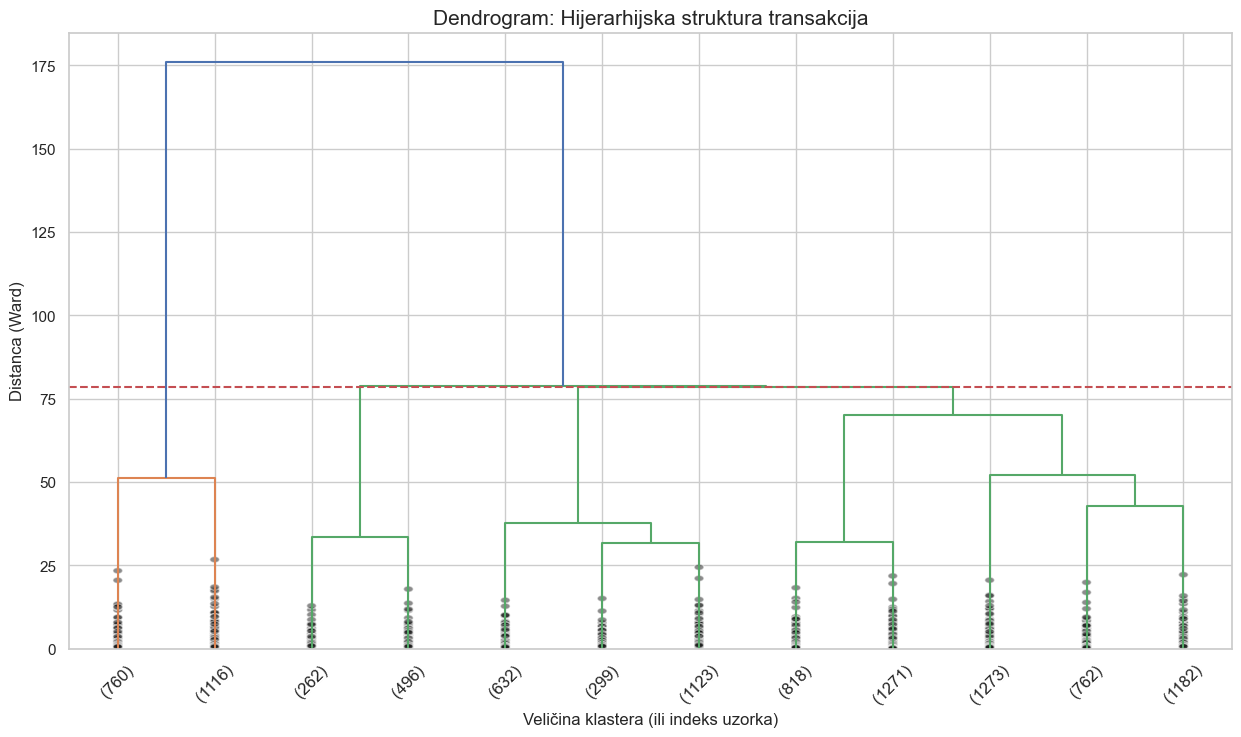

In [50]:
Z = linkage(data_final_prep_scaled, method='ward')

plt.figure(figsize=(15, 8))
plt.title('Dendrogram: Hijerarhijska struktura transakcija', fontsize=15)
plt.xlabel('Veličina klastera (ili indeks uzorka)', fontsize=12)
plt.ylabel('Distanca (Ward)', fontsize=12)


dendrogram(
    Z,
    truncate_mode='lastp',  
    p=12,                   
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True    
)
plt.axhline(y=78.5, color='r', linestyle='--') 

plt.show()


Dendogram je pokazao jednu zanimljivu stvar, a to je potvrda prethodno radjenog testa za pronalazenje najoptimalnijeg broja K, gde su svi radjeni algoritmi dali K=2 kao najbolje resenje. Medjutim, zbog prirode zadatka, izabrano je K=3, a koliko su zapravo dva klastera na desnoj strani bliska, pokazuje i to da se ne moze lepo videti gde horizontalna crvena linija preseca trecu vertikalnu liniju. MeanShift je recimo ceo taj deo grupisao zajedno.

### PCA Vizuelizacija klastera

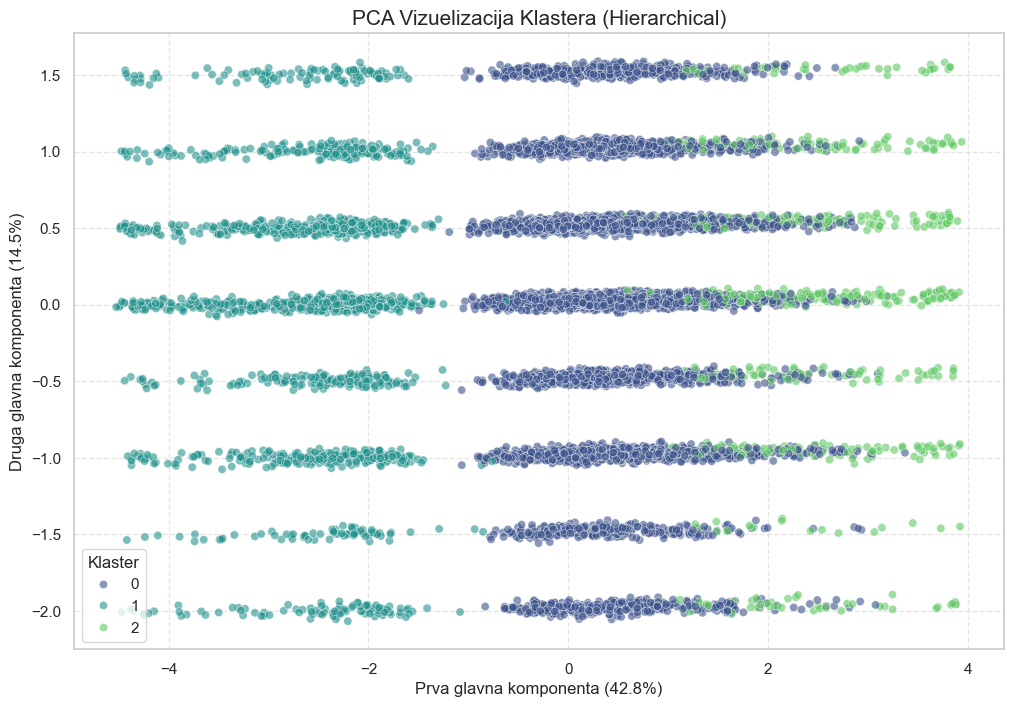

In [51]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_final_prep_scaled)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = data['Hierarchical_Labels'].astype(str) # Koristimo tvoj "pobednički" model

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    data=pca_df, 
    palette='viridis', 
    alpha=0.6,
    edgecolor='w'
)

plt.title('PCA Vizuelizacija Klastera (Hierarchical)', fontsize=15)
plt.xlabel(f'Prva glavna komponenta ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Druga glavna komponenta ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Klaster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Pomocu PCA se i graficki vidi da klasteri sa ukupno 58.2% varijanse izgledaju bas kao i u dendogramu: <br>
Klaster1 - Odvojen sa leve strane kao deficitne transakcije. <br>
Klasteri 0 i 2 - klasteri regularnih i ektremnih transakcija, cije se pojedine tacke na granici mesaju. <br>

Kako segmentacija po PC1 prati dosada dobijene rezultate, a i nosi 42.8% varijanse, to ovu komponentu najverovatnije cini povezanost profita i popusta.

-----------------------

Kako bih video zasto su uzorci podeljeni u linije po PC2, plotovacu PCA Loadings:

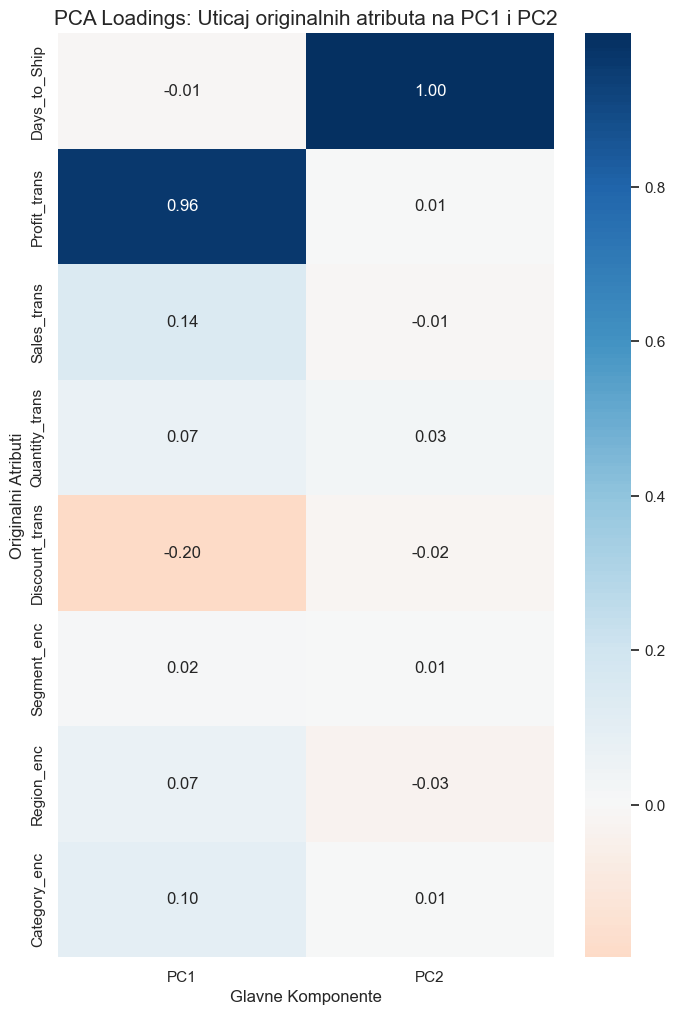

In [53]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=data_final_prep_scaled.columns
)

plt.figure(figsize=(8, 12))  
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0, fmt='.2f')

plt.title('PCA Loadings: Uticaj originalnih atributa na PC1 i PC2', fontsize=15)
plt.ylabel('Originalni Atributi')
plt.xlabel('Glavne Komponente')
plt.show()

PCA Loadings tabela:
                     PC1       PC2
Days_to_Ship   -0.007805  0.998919
Profit_trans    0.959976  0.005788
Sales_trans     0.143583 -0.010583
Quantity_trans  0.069304  0.028765
Discount_trans -0.196898 -0.015270
Segment_enc     0.016314  0.007766
Region_enc      0.068743 -0.029167
Category_enc    0.095950  0.006645


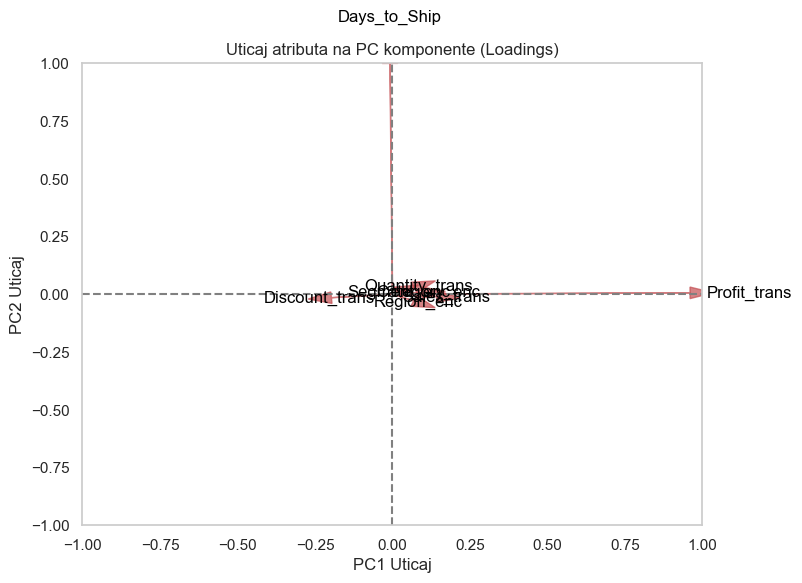

In [55]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=data_final_prep_scaled.columns # tvoji originalni atributi
)

print("PCA Loadings tabela:")
print(loadings)

# 2. Plotovanje vektora (da vidiš smer uticaja)
plt.figure(figsize=(8, 6))
for i, feature in enumerate(loadings.index):
    plt.arrow(0, 0, loadings.PC1[i], loadings.PC2[i], color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings.PC1[i]*1.2, loadings.PC2[i]*1.2, feature, color='black', ha='center', va='center')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('PC1 Uticaj')
plt.ylabel('PC2 Uticaj')
plt.title('Uticaj atributa na PC komponente (Loadings)')
plt.grid()
plt.show()

Rezultati za PC2 su zapravno nesto sto ne bih nikad predvideo, a to je brzina dostave. Podela na 8 grupa po y-osi ima smisla, jer je i broj mogucih dana za dostavu 0-7 (8 vrednosti). Ovo je korisno saznanje jer se na grafiku vidi da se sve vrste tarnsakicija gotovo podjednako nalaze u svakoj liniji y-ose, sto znaci da broj dana dostave ne utice na poslovanje. Ovo i ima smisla, jer je najcesce u praksi dostava u nadleznosti druge firme koja se bavi dostavom, a ne firme koja prodaje proizvode. 

### 3D Plot

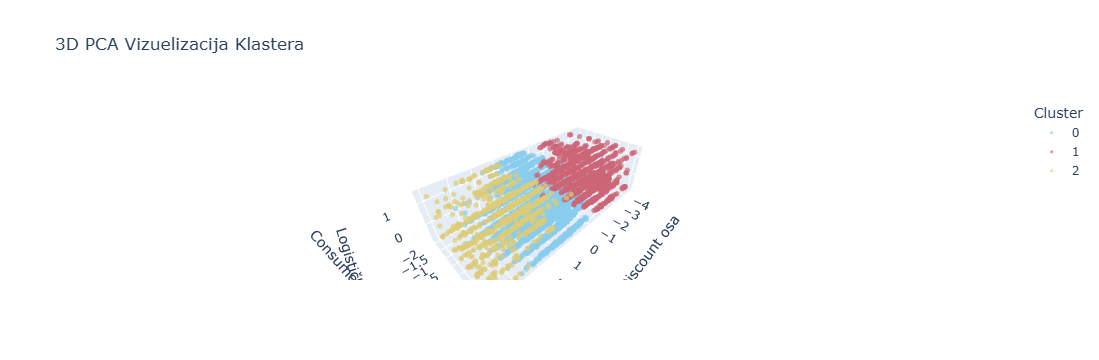

In [69]:
import plotly.express as px

pca_3d = PCA(n_components=3)
pca_data_3d = pca_3d.fit_transform(data_final_prep_scaled)

pca_df_3d = pd.DataFrame(data=pca_data_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['Cluster'] = data['Hierarchical_Labels'].astype(str)

fig = px.scatter_3d(
    pca_df_3d, 
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title='3D PCA Vizuelizacija Klastera',
    labels={'PC1': 'Profit/Discount osa', 'PC2': 'Logistička osa (Days to Ship)', 'PC3': 'Consumer'}, #Consumer u PC3 sam dodao naknadno kada sam utvrdio sta je
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(marker=dict(size=3))

fig.show()

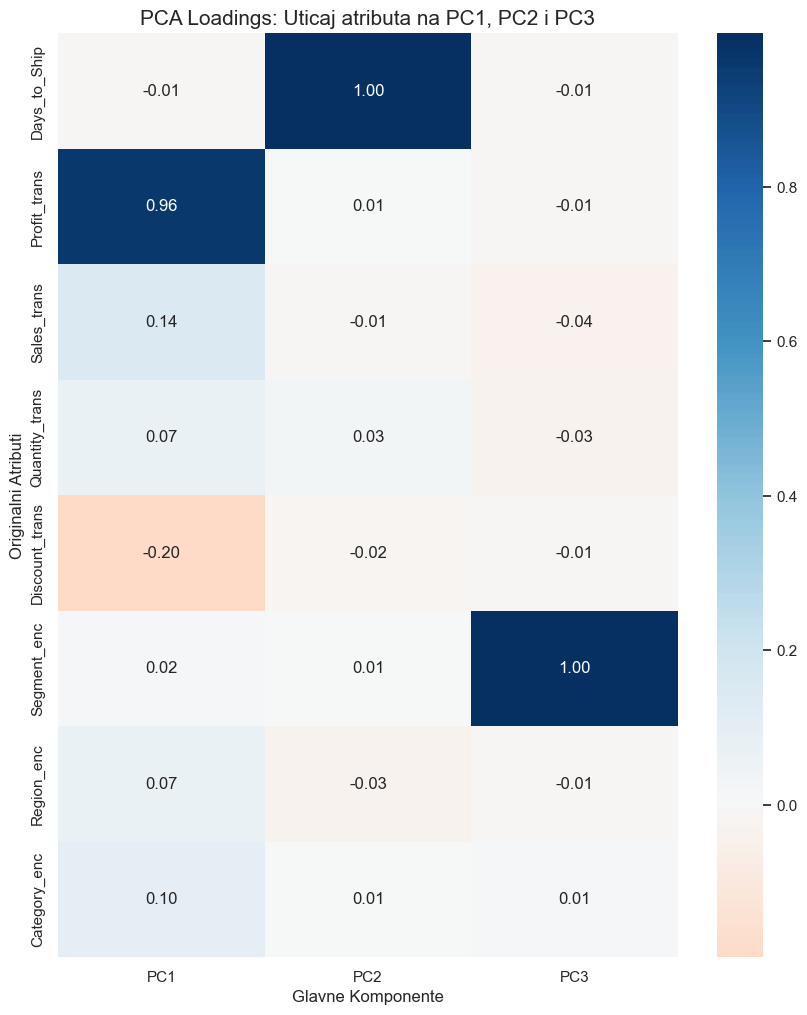

In [59]:
loadings_3d = pd.DataFrame(
    pca_3d.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=data_final_prep_scaled.columns
)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings_3d, annot=True, cmap='RdBu', center=0, fmt='.2f')

plt.title('PCA Loadings: Uticaj atributa na PC1, PC2 i PC3', fontsize=15)
plt.ylabel('Originalni Atributi')
plt.xlabel('Glavne Komponente')
plt.show()

PC3, odnosno z-osa zapravo cini Segment, odnosno iz kojih segmenata dolaze transakcije (potrosaci), sto opet ima smisla jer mi se skup podelio sada na tri grupe po z-osi, a Segment i cine Consumer, Corporate, Home Office. <br>
Ponovo kao i kod brzine dostave i ovde moze se zakljuciti da su sve tri grupe transakcija prisutne kod svakog tipa potrosaca - ovo je od znacaja jer se moze graficki videti politika kupovine svakog od njih. <br>

In [64]:
pca_3d.explained_variance_ratio_

array([0.4281796 , 0.1446524 , 0.11002158])

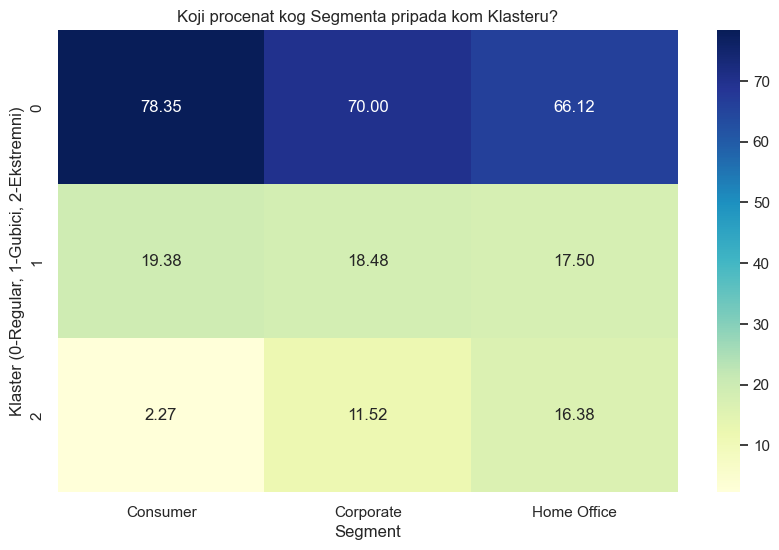

In [68]:
segment_pct = pd.crosstab(
    data['Hierarchical_Labels'], 
    data['Segment'], 
    normalize='columns'
) * 100





plt.figure(figsize=(10, 6))
sns.heatmap(segment_pct, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Koji procenat kog Segmenta pripada kom Klasteru?')
plt.ylabel('Klaster (0-Regular, 1-Gubici, 2-Ekstremni)')
plt.show()

Na osnovu brojki, zapravo se moze videti da se obicni kupci (Consumer) najredje odlucuju na ekstremnu kupovinu, sto je logicno, jer imaju najmanje sredstava, ali zato najvise doprinose gubicima jer hvataju velike popuste. <br>
Mali poslovi (Home Office) imaju najbalansiraniju raspodelu kupovina i time su nasi najzahvalniji kupci. Ovo je dokaz da su ranije pravilno enkodirani najvecom vrednoscu. <br>
Korporacije su negde izmedju, fokusirane na standardnu kupovinu, koriste popuste kada mogu, ali nemaju problema i da izvrse ekstremnu transakciju.

-----------------

## Zakljucak - Deskriptivna analiza rezultata

In [ ]:
cols_to_drop = ['KMeans_Labels', 'HDBSCAN_Labels', 'HDBSCAN_Labels_V2', 'MeanShift_Labels']
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])


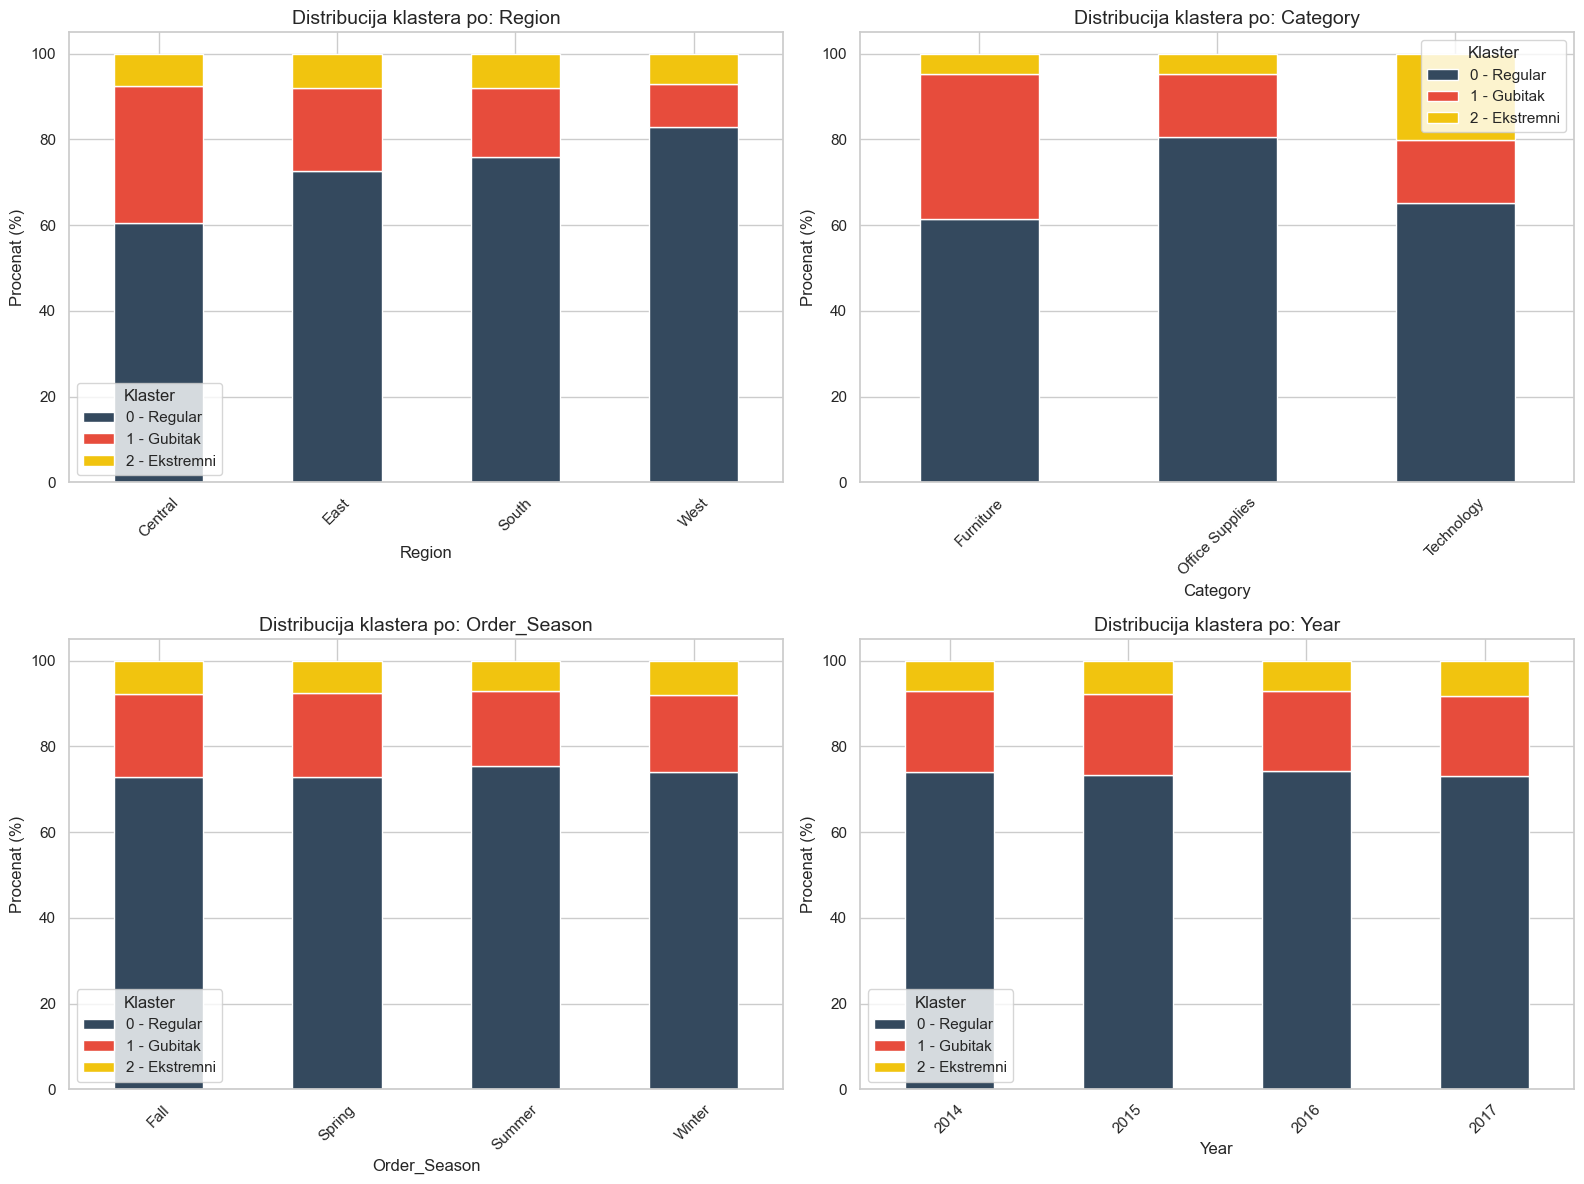

In [76]:
features_to_plot = ['Region', 'Category', 'Order_Season', 'Year']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    temp_pct = pd.crosstab(data[col], data['Hierarchical_Labels'], normalize='index') * 100
    
    
    temp_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#34495e', '#e74c3c', '#f1c40f'])
    
    axes[i].set_title(f'Distribucija klastera po: {col}', fontsize=14)
    axes[i].set_ylabel('Procenat (%)')
    axes[i].legend(title='Klaster', labels=['0 - Regular', '1 - Gubitak', '2 - Ekstremni'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Dobijeni su sledeci zakljuci: <br>
1. Region: Treba popraviti poslovanje u Central regionu.
2. Category: Treba popraviti poslovanje za Furniture kategoriju robe.
3. Order Season: Nema znacajniog ukazatelja za promenu.
4. Year: Nema znacajnog ukazatelja za promenu, ali svakako da bi trebalo teziti ka smanjenju gubitaka naredne godine.

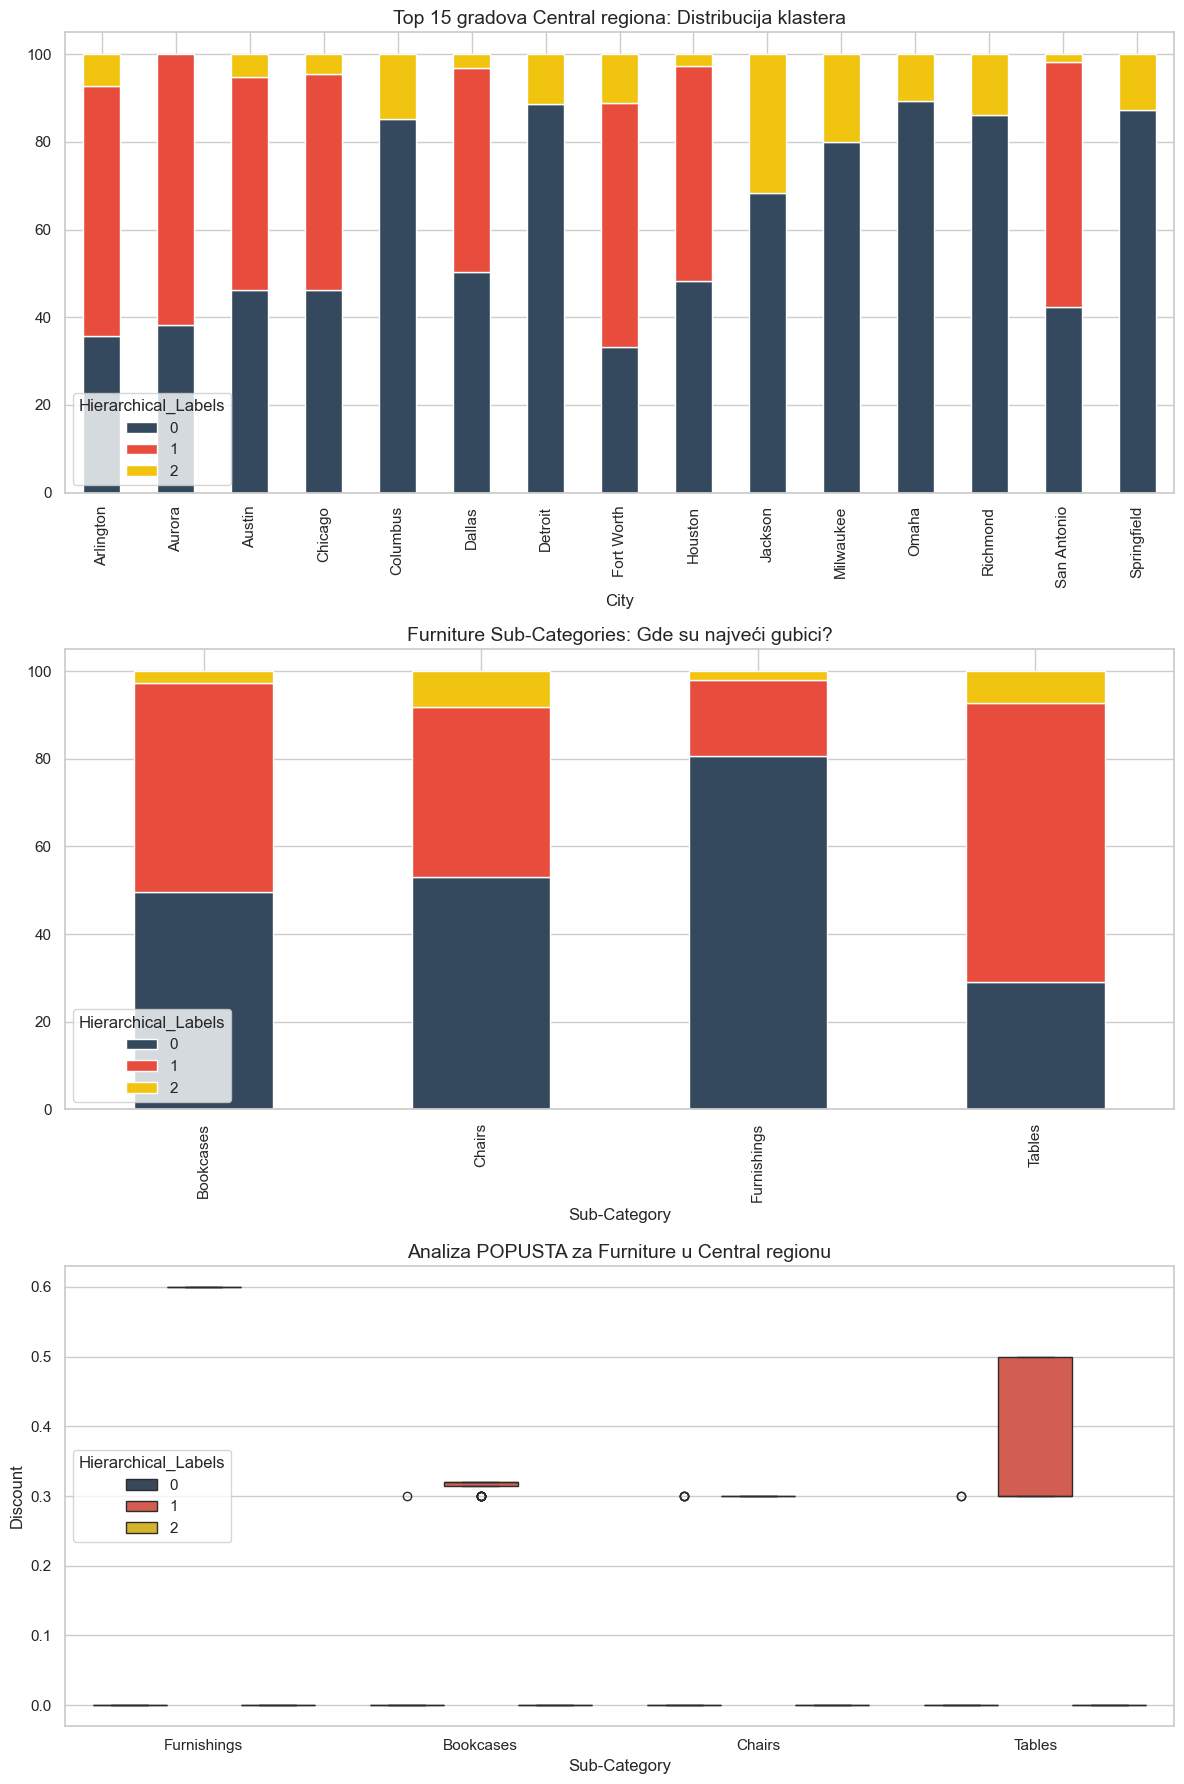

In [78]:
central_data = data[data['Region'] == 'Central']
furniture_data = data[data['Category'] == 'Furniture']
central_furniture = data[(data['Region'] == 'Central') & (data['Category'] == 'Furniture')]

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

top_cities = central_data['City'].value_counts().nlargest(15).index
central_cities_pct = pd.crosstab(central_data[central_data['City'].isin(top_cities)]['City'], 
                                 central_data['Hierarchical_Labels'], normalize='index') * 100
central_cities_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#34495e', '#e74c3c', '#f1c40f'])
axes[0].set_title('Top 15 gradova Central regiona: Distribucija klastera', fontsize=14)

furniture_sub_pct = pd.crosstab(furniture_data['Sub-Category'], 
                                furniture_data['Hierarchical_Labels'], normalize='index') * 100
furniture_sub_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#34495e', '#e74c3c', '#f1c40f'])
axes[1].set_title('Furniture Sub-Categories: Gde su najveći gubici?', fontsize=14)

sns.boxplot(x='Sub-Category', y='Discount', hue='Hierarchical_Labels', data=central_furniture, ax=axes[2], palette=['#34495e', '#e74c3c', '#f1c40f'])
axes[2].set_title('Analiza POPUSTA za Furniture u Central regionu', fontsize=14)

plt.tight_layout()
plt.show()

Sada su izvuceni gradovi u centralnom regionu kod kojih je potrebno popraviti poslovanje i kod kojih komada namestaja je generalno potrebno potraviti poslovanje. <br>
Takodje vidimo i da su procenti popusta na namestaj u centralnom regionu prosecno veliki (preko 30%).